In [1]:
import pandas as pd
pd.set_option('display.max_columns', None)
import gc
import os
import importlib
from importlib import reload
import cv2
from tqdm.auto import tqdm
from collections import defaultdict

import ast
import seaborn as sns
import numpy as np
import os
import sys
import torch
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pathlib import Path
from PIL import Image
import hashlib
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

from sklearn.metrics import roc_auc_score


os.chdir('..') # 상위 경로 이동
print("현재 경로:", os.getcwd())
root_dir = '/home/DAHS1/gangmin/my_research/'
new_dir_path = "/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/"

현재 경로: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning


In [2]:
sequential_df_med = pd.read_feather(new_dir_path + "processed/sequential_df_med.ftr")
sequential_df_output = pd.read_feather(root_dir + "processed/processed_1013/sequential_df_output.ftr")
# imputed_df_chart = pd.read_feather(root_dir + "processed/imputed_df_chart_1223.ftr")
imputed_df_chart = pd.read_feather(new_dir_path + "processed/imputed_df_chart_20260423.ftr")
sequential_df_proc = pd.read_feather(new_dir_path + "processed/sequential_df_proc.ftr")
sequential_df_fluid = pd.read_feather(new_dir_path + "processed/sequential_df_fluid.ftr")

imputed_cxr_df = pd.read_feather(new_dir_path + '/processed/imputed_cxr_df_20260428.ftr')
imputed_text_df = pd.read_feather(root_dir+'/processed/imputed_text_df.ftr')
sequential_df_reports = pd.read_feather(root_dir + "processed/sequential_df_reports.ftr")

In [3]:
imputed_df_chart['itemid'].nunique()

19

In [4]:
# 결측값 제로 패딩
sequential_df_output['urine_output'] = sequential_df_output['urine_output'].fillna(0)
sequential_df_med['input_amount'] = sequential_df_med['input_amount'].fillna(0)
sequential_df_fluid['input_amount'] = sequential_df_fluid['input_amount'].fillna(0)

In [5]:
imputed_cxr_df['Edema'].value_counts()

Edema
 0.0    35162
 1.0    12411
-1.0     4496
Name: count, dtype: int64

---

In [6]:
imputed_df_chart.columns

Index(['stay_id', 'itemid', 'hour_slot', 'slot_start', 'value'], dtype='object')

In [7]:
df_pivot_value = imputed_df_chart.pivot_table(
    index=['stay_id', 'hour_slot'],   
    columns='itemid',                
    values=['value']
).reset_index()

df_pivot_value.columns = [
    str(col[1]) if col[0] == 'value' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_value.columns.values
]

In [8]:
df_pivot_value

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,100.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0


In [9]:
df_pivot_value.isnull().sum()

stay_id_      0
hour_slot_    0
50963         0
220045        0
220179        0
220180        0
220210        0
220277        0
220546        0
220615        0
220645        0
223761        0
223835        0
225624        0
225668        0
227073        0
227429        0
227442        0
227445        0
227446        0
227456        0
dtype: int64

In [10]:
mask = df_pivot_value['223835'] != -2
df_pivot_value.loc[mask, '223835'] = (df_pivot_value.loc[mask, '223835'] / 100)

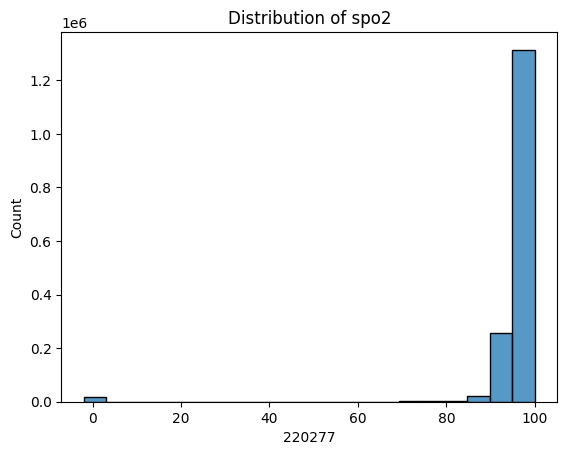

In [11]:
sns.histplot(df_pivot_value['220277'], bins=20)
plt.title('Distribution of spo2')
plt.show()

In [12]:
df_pivot_value

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0


In [13]:
def calculate_spo2_fio2(spo2, fio2):
    # -2가 있으면 NaN
    if spo2 == -2 or fio2 == -2:
        return np.nan
    # FiO2가 0이면 NaN (division by zero 방지)
    elif fio2 == 0.0:
        return np.nan
    else:
        return spo2 / fio2

df_pivot_value['spo2_fio2'] = df_pivot_value.apply(
    lambda row: calculate_spo2_fio2(row["220277"], row['223835']), 
    axis=1
)

In [14]:
df_pivot_value['220277']

0          97.500000
1          94.000000
2          98.000000
3          98.000000
4          94.363636
             ...    
1618766    95.000000
1618767    94.000000
1618768    93.000000
1618769    93.000000
1618770    93.000000
Name: 220277, Length: 1618771, dtype: float64

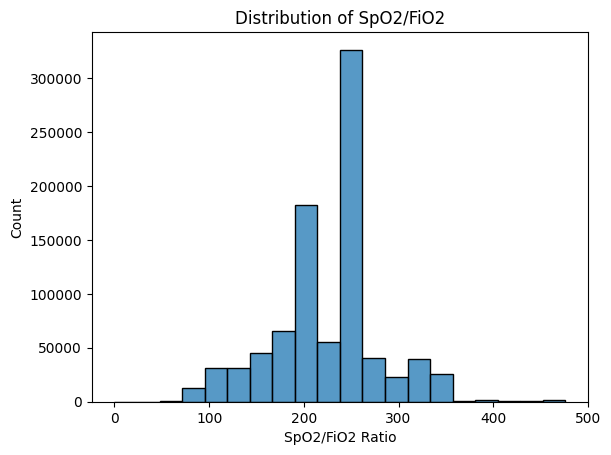

In [15]:
sns.histplot(df_pivot_value['spo2_fio2'], bins=20)
plt.title('Distribution of SpO2/FiO2')
plt.xlabel('SpO2/FiO2 Ratio')
plt.show()

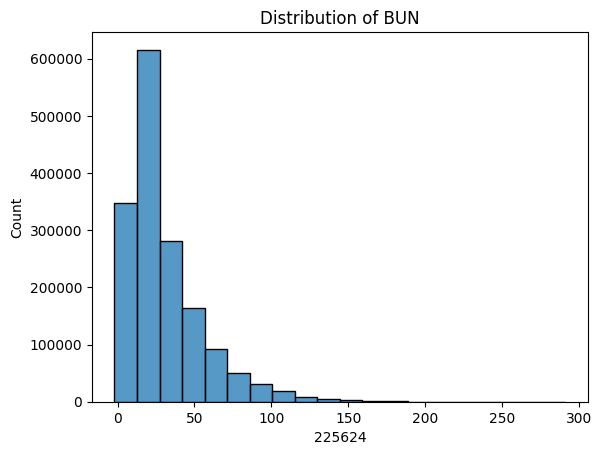

In [16]:
sns.histplot(df_pivot_value['225624'], bins=20)
plt.title('Distribution of BUN')
plt.show()

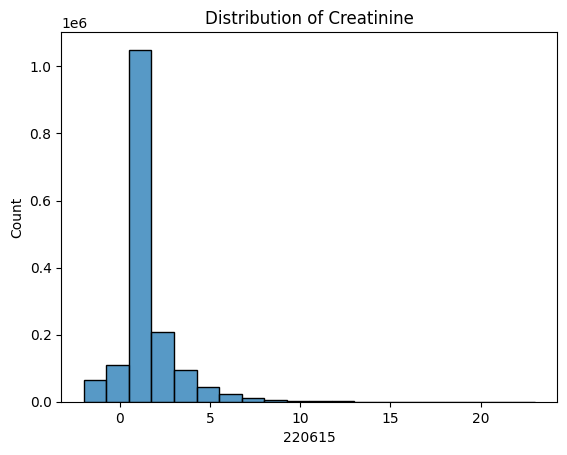

In [17]:
sns.histplot(df_pivot_value['220615'], bins=20)
plt.title('Distribution of Creatinine')
plt.show()

In [18]:
# BUN / Creatinine
def calculate_bun_creatinine(bun, creatinine):
    # -2가 있으면 NaN
    if bun == -2 or creatinine == -2:
        return np.nan
    # creatinine 0이면 NaN (division by zero 방지)
    elif creatinine == 0.0:
        return np.nan
    else:
        return bun / creatinine

df_pivot_value['bun_creatinine'] = df_pivot_value.apply(
    lambda row: calculate_bun_creatinine(row["225624"], row['220615']), 
    axis=1
)

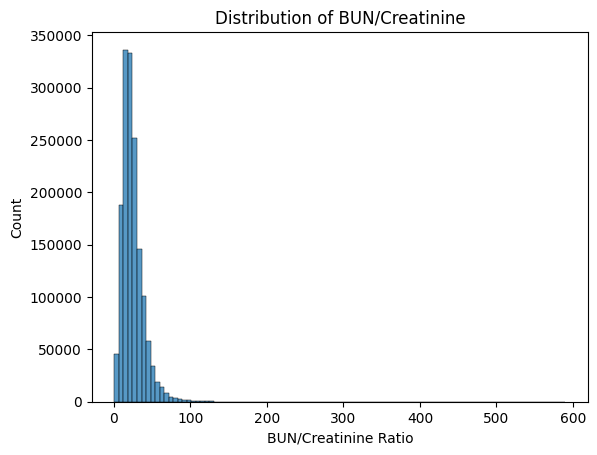

In [19]:
sns.histplot(df_pivot_value['bun_creatinine'], bins=100)
plt.title('Distribution of BUN/Creatinine')
plt.xlabel('BUN/Creatinine Ratio')
plt.show()

In [20]:
df_pivoted_chart = df_pivot_value.copy()
df_pivoted_chart

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,NaN,12.5
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0,NaN,34.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,NaN,38.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,NaN,38.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,NaN,38.0


In [21]:
# 같은 S/F라고 하더라도, FiO2 0.3에서 S/F 250과 FiO2 0.8에서 S/F 250의 치료 강도가 완전히 다르기 때문에, S/F+FiO2 조합을 사용하기로 해서, SpO2는 drop함.
df_pivoted_chart['spo2_fio2'] = (df_pivoted_chart['spo2_fio2'].fillna(-2))
df_pivoted_chart['bun_creatinine'] = (df_pivoted_chart['bun_creatinine'].fillna(-2))
df_pivoted_chart

,stay_id_,hour_slot_,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636,12.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0,-2.000000,34.0
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0


In [22]:
sequential_df_med.columns

Index(['hadm_id', 'stay_id', 'hour_slot', 'slot_start', 'slot_end', 'itemid',
       'input_amount'],
      dtype='object')

In [23]:
# input
df_pivot_input = sequential_df_med.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='itemid',                
    values=['input_amount']
).reset_index()

df_pivot_input.columns = [
    str(col[1]) if col[0] == 'input_amount' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_input.columns.values
]

df_pivot_input

,stay_id_,hour_slot_,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974
0,30000646,0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1,30000646,1,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
2,30000646,2,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
3,30000646,3,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
4,30000646,4,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1618767,39998622,212,0.0,0.0,0.0,40.000003,0.0,0.0,0.0,0.0,0.0,0.0
1618768,39998622,213,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0
1618769,39998622,214,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
print(sequential_df_proc['stay_id'].nunique())
print(sequential_df_proc['hadm_id'].nunique())

14146
12985


In [25]:
hadm_df = sequential_df_proc[['hadm_id', 'stay_id']].drop_duplicates().reset_index(drop=True)
hadm_df

,hadm_id,stay_id
0,26184834,37510196
1,23473524,35479615
2,28662225,33987268
3,28662225,38875437
4,20214994,32128372
...,...,...
14141,24096838,33428243
14142,24842066,30988867
14143,20175828,35165301
14144,26785317,32336619


In [26]:
# procedure
df_pivot_proc = sequential_df_proc.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='itemid',                
    values=['procedure_flag']
).reset_index()

df_pivot_proc.columns = [
    str(col[1]) if col[0] == 'procedure_flag' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_proc.columns.values
]

df_pivot_proc

,stay_id_,hour_slot_,225402,225794
0,30000646,0,1.0,0.0
1,30000646,1,0.0,0.0
2,30000646,2,0.0,0.0
3,30000646,3,0.0,0.0
4,30000646,4,1.0,0.0
...,...,...,...,...
1618766,39998622,211,0.0,0.0
1618767,39998622,212,0.0,0.0
1618768,39998622,213,0.0,0.0
1618769,39998622,214,0.0,0.0


In [27]:
sequential_df_output

,hadm_id,stay_id,hour_slot,slot_start,slot_end,urine_output
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,0.000000
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0.000000
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,92.048611
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,215.296022
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,123.782818
...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0.000000
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0.000000
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,303.333333
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,21.666667


In [28]:
sequential_df_output = sequential_df_output[['stay_id', 'hour_slot', 'urine_output']]
sequential_df_output = sequential_df_output.rename(columns={'urine_output': 'urine'})
sequential_df_output = sequential_df_output.sort_values(['stay_id', 'hour_slot']).reset_index(drop=True)

In [29]:
sequential_df_output

,stay_id,hour_slot,urine
0,30000646,0,0.000000
1,30000646,1,0.000000
2,30000646,2,0.000000
3,30000646,3,529.277778
4,30000646,4,170.722222
...,...,...,...
1618766,39998622,211,40.473164
1618767,39998622,212,292.896153
1618768,39998622,213,478.226729
1618769,39998622,214,175.741525


In [30]:
sequential_df_fluid

,hadm_id,stay_id,hour_slot,slot_start,slot_end,fluid_category,input_amount
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,fluid_alb,0.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,fluid_alb,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,fluid_alb,0.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,fluid_alb,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,fluid_alb,0.0
...,...,...,...,...,...,...,...
3237537,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,fluid_cyst,0.0
3237538,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,fluid_cyst,0.0
3237539,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,fluid_cyst,0.0
3237540,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,fluid_cyst,201.2


In [31]:
# fluid
df_pivot_fluid = sequential_df_fluid.pivot_table(
    index=['stay_id', 'hour_slot'],
    columns='fluid_category',                
    values=['input_amount']
).reset_index()

df_pivot_fluid.columns = [
    str(col[1]) if col[0] == 'input_amount' else f'{col[0]}_{str(col[1])}'
    for col in df_pivot_fluid.columns.values
]

df_pivot_fluid

,stay_id_,hour_slot_,fluid_alb,fluid_cyst
0,30000646,0,0.0,320.614289
1,30000646,1,0.0,5.000507
2,30000646,2,0.0,5.000507
3,30000646,3,0.0,5.000507
4,30000646,4,0.0,3365.000507
...,...,...,...,...
1618766,39998622,211,0.0,105.000000
1618767,39998622,212,0.0,5.000000
1618768,39998622,213,0.0,5.000000
1618769,39998622,214,0.0,5.000000


In [32]:
df_pivoted_chart = df_pivoted_chart.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
df_pivot_input = df_pivot_input.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
df_pivot_fluid = df_pivot_fluid.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})
df_pivot_proc = df_pivot_proc.rename(columns={'stay_id_': 'stay_id', 'hour_slot_': 'hour_slot'})

from functools import reduce

def merge_all_icu_events(df_chart, df_med, df_fluid, df_proc, df_output):    
    dataframes = [df_chart, df_med, df_fluid, df_proc, df_output]

    icu_events = reduce(lambda left, right: pd.merge(left, right, on=['stay_id', 'hour_slot'], how='left'), dataframes)

    icu_events.columns = icu_events.columns.map(str)

    return icu_events

icu_events_df = merge_all_icu_events(df_pivoted_chart, df_pivot_input, df_pivot_fluid, df_pivot_proc, sequential_df_output)

In [33]:
icu_events_df

,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine
0,30000646,0,-2.0,101.000000,109.000000,65.500000,30.500000,97.500000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,320.614289,1.0,0.0,0.000000
1,30000646,1,-2.0,97.000000,97.000000,58.000000,19.000000,94.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000507,0.0,0.0,0.000000
2,30000646,2,-2.0,93.000000,98.000000,57.000000,18.000000,98.000000,8.433333,0.933333,137.666667,-2.000000,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000507,0.0,0.0,0.000000
3,30000646,3,-2.0,87.000000,98.000000,66.000000,24.000000,98.000000,8.433333,0.933333,137.666667,37.111111,-2.0,11.666667,-2.0,12.0,-2.00,3.666667,-2.0,-2.0,-2.0,-2.000000,12.5,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000507,0.0,0.0,529.277778
4,30000646,4,-2.0,90.454545,96.714286,61.428571,30.454545,94.363636,10.600000,1.000000,141.000000,39.111111,1.0,12.000000,-2.0,12.0,0.02,3.700000,1.0,-2.0,-2.0,94.363636,12.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3365.000507,1.0,0.0,170.722222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,39998622,211,-2.0,113.000000,114.000000,75.000000,38.000000,95.000000,12.400000,1.000000,140.000000,36.888889,-2.0,34.000000,-2.0,14.0,-2.00,4.200000,-2.0,-2.0,-2.0,-2.000000,34.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,105.000000,0.0,0.0,40.473164
1618767,39998622,212,-2.0,111.000000,120.000000,71.000000,23.000000,94.000000,12.400000,1.000000,139.000000,36.888889,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0,0.0,0.0,0.0,40.000003,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,0.0,0.0,292.896153
1618768,39998622,213,-2.0,108.000000,127.000000,82.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,0.0,0.0,478.226729
1618769,39998622,214,-2.0,106.000000,120.000000,71.000000,35.000000,93.000000,12.400000,1.000000,139.000000,36.944444,-2.0,38.000000,-2.0,12.0,-2.00,3.900000,-2.0,-2.0,-2.0,-2.000000,38.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.000000,0.0,0.0,175.741525


In [34]:
icu_events_df = hadm_df.merge(icu_events_df, how='left', on='stay_id')
icu_events_df = icu_events_df.sort_values(by=['hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
icu_events_df

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661


In [35]:
icu_events_df.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine'],
      dtype='object')

In [36]:
# icu_events_df.to_feather("/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/icu_events_df.ftr")

In [37]:
imputed_cxr_df['Edema'].value_counts()

Edema
 0.0    35162
 1.0    12411
-1.0     4496
Name: count, dtype: int64

In [38]:
test = imputed_cxr_df[imputed_cxr_df['image_path'].notnull()]

In [39]:
test

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
24,26184834,37510196,24,2131-01-12 04:20:05,2131-01-12 05:20:05,1,files/p10/p10001884/s50712381/7b25b3ed-e780a52...,2131-01-12 04:56:56.359,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
48,26184834,37510196,48,2131-01-13 04:20:05,2131-01-13 05:20:05,1,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...,2131-01-13 04:49:18.484,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0
78,26184834,37510196,78,2131-01-14 10:20:05,2131-01-14 11:20:05,1,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...,2131-01-14 10:34:28.765,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,1.0,0.0,-1.0,0.0,-1.0,0.0,1.0,1.0
96,26184834,37510196,96,2131-01-15 04:20:05,2131-01-15 05:20:05,1,files/p10/p10001884/s50376803/469d0d94-3dad506...,2131-01-15 04:45:09.078,0.0,1.0,-1.0,0.0,0.0,0.0,0.0,-1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618525,20175828,35165301,81,2197-08-07 09:02:00,2197-08-07 10:02:00,1,files/p19/p19999287/s52519175/f7e95a22-cb95805...,2197-08-07 09:06:37.796,0.0,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
1618543,20175828,35165301,99,2197-08-08 03:02:00,2197-08-08 04:02:00,1,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...,2197-08-08 03:15:49.890,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
1618565,26785317,32336619,8,2148-11-19 22:23:43,2148-11-19 23:23:43,1,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...,2148-11-19 22:47:03.375,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1618730,23865745,36195440,6,2145-11-03 04:59:00,2145-11-03 05:59:00,1,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...,2145-11-03 05:05:07.625,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [40]:
CXR_LABEL_COLS = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
    'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
]

# chexpert U-Ones (Uncertain to Positive)
# imputed_cxr_df.loc[:, CXR_LABEL_COLS] = imputed_cxr_df[CXR_LABEL_COLS].fillna(0)
imputed_cxr_df.loc[:, CXR_LABEL_COLS] = imputed_cxr_df[CXR_LABEL_COLS].replace(-1, 1)

In [41]:
imputed_cxr_df

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0


In [42]:
# 리샘플링 데이터셋에 라벨 할당 
def static_cxr_edema_labeling(df, cols, identifier, limit_hours=0): # 과거 limit_hours=24
    processed_list = []

    for stay_id, group in df.groupby(identifier):
        group = group.copy()

        current_labels = {col: None for col in cols}
        label_start_hours = {col: None for col in cols}
        label_source = [None] * len(group)

        # cxr 라벨 기준 라벨 추출
        for i, (idx, row) in enumerate(group.iterrows()):
            row_source = None
            
            for col in cols:
                if row['cxr_flag']==1 and not pd.isna(row[col]):
                    current_labels[col] = row[col]
                    label_start_hours[col] = row['hour_slot']
                    group.at[idx, col] = current_labels[col]
                    row_source = 'original'

                elif current_labels[col] is not None:
                    hour_diff = row['hour_slot'] - label_start_hours[col]

                    if hour_diff <= limit_hours:
                        group.at[idx, col] = current_labels[col]
                        if row_source is None:
                            row_source = 'ffilled'
                    else: 
                        current_labels[col] = None
                        label_start_hours[col] = None

            label_source[i] = row_source
        
        group['label_source'] = label_source
        processed_list.append(group)

    df = pd.concat(processed_list).sort_index()
    return df

label_imputed_cxr = static_cxr_edema_labeling(imputed_cxr_df, cols=CXR_LABEL_COLS, identifier='stay_id', limit_hours=0)

In [43]:
label_imputed_cxr

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing,label_source
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,original
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None


In [44]:
label_imputed_cxr

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,was_missing,label_source
0,26184834,37510196,0,2131-01-11 04:20:05,2131-01-11 05:20:05,1,files/p10/p10001884/s57156853/9fd47edd-0708720...,2131-01-10 12:54:30.328,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,original
1,26184834,37510196,1,2131-01-11 05:20:05,2131-01-11 06:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
2,26184834,37510196,2,2131-01-11 06:20:05,2131-01-11 07:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
3,26184834,37510196,3,2131-01-11 07:20:05,2131-01-11 08:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
4,26184834,37510196,4,2131-01-11 08:20:05,2131-01-11 09:20:05,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,2145-11-04 16:59:00,2145-11-04 17:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618767,23865745,36195440,43,2145-11-04 17:59:00,2145-11-04 18:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618768,23865745,36195440,44,2145-11-04 18:59:00,2145-11-04 19:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None
1618769,23865745,36195440,45,2145-11-04 19:59:00,2145-11-04 20:59:00,0,None,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,None


In [45]:
# 이렇게 하면 거의 97%가 결측 라벨임.
label_imputed_cxr['Edema'].value_counts()

Edema
0.0    35162
1.0    16907
Name: count, dtype: int64

In [46]:
label_imputed_cxr.to_feather('/home/DAHS1/gangmin/my_research/processed/label_imputed_cxr_20260428.ftr')

In [47]:
CXR_LABEL_COLS

['Atelectasis',
 'Cardiomegaly',
 'Consolidation',
 'Edema',
 'Enlarged Cardiomediastinum',
 'Fracture',
 'Lung Lesion',
 'Lung Opacity',
 'No Finding',
 'Pleural Effusion',
 'Pleural Other',
 'Pneumonia',
 'Pneumothorax',
 'Support Devices']

In [48]:
# stay_id별 라벨 정리
labeling = label_imputed_cxr[['stay_id', 'hour_slot', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
    'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']]
labeling

,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618767,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618768,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618769,36195440,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


---

In [49]:
ts_dataset = icu_events_df.merge(labeling, how='left', on=['stay_id', 'hour_slot'])
ts_dataset

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [50]:
ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices'],
      dtype='object')

In [51]:
feature_cols = [
    '50963', '220045', '220179', '220180', '220210', '220277', '220546', '220615', '220645', '223761',
    '223835', '225624', '225668', '227073', '227429', '227442', '227445', '227446', '227456', 'spo2_fio2', 
    'bun_creatinine', '221653', '221662', '221749', '221794', '221906', '221986', '222051', '222056', '225168',
    '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine'
]

In [52]:
ts_dataset

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [53]:
def feature_statistics(series):
    nonzero = series[(series != -2) & (~series.isna())] # -2 sentinel
    return pd.Series({
        'min': nonzero.min(),
        'max': nonzero.max(),
        'median': nonzero.median(),
        'mean': nonzero.mean(),
        'std': nonzero.std(),
        'valid count': nonzero.count(),
        'missing count': len(ts_dataset) - nonzero.count(),
        'missing_rate': round((len(ts_dataset) - nonzero.count()) / len(ts_dataset), 4)
    })

In [54]:
vital_cols = ['220045', '220179', '220180', '220210', '220277', '223761', '223835'] # fio2는 엄밀히 vital 아님.
lab_cols = ['227429', '227446', '225624', '227073', '220645', '227442', '227456', '227445', '220615', '220546', '225668', '50963']

In [55]:
vital_stats_df = ts_dataset[vital_cols].apply(feature_statistics).T
vital_stats_df

,min,max,median,mean,std,valid count,missing count,missing_rate
220045,1.00,247.5,86.000000,87.241896,17.956831,1606591.0,12180.0,0.0075
220179,11.00,280.0,118.000000,119.852100,21.955275,1117614.0,501157.0,0.3096
220180,10.00,175.0,62.333333,64.046461,15.544256,1117503.0,501268.0,0.3097
220210,1.00,60.0,20.000000,20.492363,5.857930,1601549.0,17222.0,0.0106
220277,0.00,100.0,97.000000,96.829515,3.520831,1599825.0,18946.0,0.0117
223761,32.00,42.3,36.944444,37.011790,0.567307,1491291.0,127480.0,0.0788
223835,0.21,1.0,0.400000,0.467517,0.147240,884923.0,733848.0,0.4533


In [56]:
lab_stats_df = ts_dataset[lab_cols].apply(feature_statistics).T
lab_stats_df

,min,max,median,mean,std,valid count,missing count,missing_rate
227429,0.01,9.25,0.07,0.556779,1.380223,208219.0,1410552.0,0.8714
227446,47.70,67806.90,4108.00,9458.676823,12394.306313,92397.0,1526374.0,0.9429
225624,1.00,291.00,24.00,31.455010,24.606525,1552591.0,66180.0,0.0409
227073,5.00,50.00,14.00,14.518810,3.923937,1550589.0,68182.0,0.0421
220645,85.00,187.00,139.00,138.720153,5.443040,1559417.0,59354.0,0.0367
227442,1.00,10.00,4.00,4.046484,0.553238,1560474.0,58297.0,0.0360
227456,1.00,6.00,2.90,2.957576,0.657734,301927.0,1316844.0,0.8135
227445,1.00,245.02,4.00,14.747066,32.166007,197028.0,1421743.0,0.8783
220615,0.00,23.00,1.00,1.525702,1.481579,1552767.0,66004.0,0.0408
220546,0.10,194.60,10.80,12.380918,8.316762,1539469.0,79302.0,0.0490


---

## 라벨링 수정 (Ver: 20260330)

In [53]:
# def valid_features(row, col):
#     return (row[col] != -2)

# # 환자가 저산소증이 있으면 cardio 환자라고 하더라도 NCPE 지표도 떨어지기는 함.
# # 그리고 NCPE early stage는 CPE와 Overlap이 많이 됨.

# def silver_standard_for_edema(row):
#     cpe_score = 0.0
#     ncpe_score = 0.0

#     bnp_score = 0.0
#     ntprobnp_score = 0.0

#     # Cardio
#     # ----- (1) BNP -----
#     if valid_features(row, '227446'):
#         bnp = row['227446']
#         if bnp > 500: 
#             bnp_score += 3.0
#         elif bnp >= 250:
#             bnp_score += 2.0

#     # ----- (2) NTproBNP -----
#     if valid_features(row, '50963'):
#         nt_bnp = row['50963']
#         if nt_bnp > 5000:
#             ntprobnp_score += 3.0
#         elif nt_bnp > 900:
#             ntprobnp_score += 2.0

#     cpe_score += max(bnp_score, ntprobnp_score)

#     # ----- (3) CK-MB -----
#     if valid_features(row, '227445'):
#         ck_mb = row['227445']
#         if ck_mb > 5.0:
#             cpe_score += 1.5

#     # ----- (4) BUN -----
#     if valid_features(row, '225624'):
#         bun = row['225624']
#         if bun > 30:
#             cpe_score += 1.0

#     # ----- (5) Troponin-T -----
#     if valid_features(row, '227429'):
#         troponin = row['227429']
#         if troponin >= 0.0135:
#             cpe_score += 1.0

#     # Non-cardio
#     # ----- (1) SpO₂ / FiO₂ -----
#     spo2_fio2 = row.get('spo2_fio2', -2)
#     fio2 = row.get('223835', -2)

#     if valid_features(row, 'spo2_fio2'):
#         spo2_fio2 = row.get('spo2_fio2')
#         if spo2_fio2 < 150:
#             ncpe_score += 2.0
#         # ARDS
#         elif (spo2_fio2 >= 150) & (spo2_fio2 < 235): 
#             ncpe_score += 1.0
#         # ALI
#         elif (spo2_fio2 >= 235) & (spo2_fio2 < 315): # cardio는 overlap 될 수도 있음.
#             ncpe_score += 0.25

#     # ----- (2) FiO₂ -----
#     if valid_features(row, '223835'):
#         fio2 = row.get('223835')
#         if fio2 >= 0.6:
#             ncpe_score += 0.5
#         elif fio2 >= 0.4:
#             ncpe_score += 0.25

#     # ----- (3) Interaction -----
#     if (spo2_fio2 != -2) and (fio2 != -2):
#         if (spo2_fio2 < 235) and (fio2 >= 0.50): # 산소를 꽤 주고 있는데도 산소화가 나쁘다 -> 폐 손상 가능성 매우 높음.
#             ncpe_score += 0.5

#         if (spo2_fio2 < 150) and (fio2 >= 0.60): # 산소를 매우 공급하고 있으면서 산소화가 점점 낮아지는 최악의 현상. (추가 가산함.)
#             ncpe_score += 1.0  

#     # ----- (4) Albumin -----
#     if valid_features(row, '227456'):
#         albumin = row['227456']
#         if albumin < 2.9:
#             ncpe_score += 1.0
#         elif albumin < 3.5:
#             ncpe_score += 0.5

#     # # ----- (5) Temperature -----
#     if valid_features(row, '223761'):
#         temperature = row['223761']
#         if temperature > 38.3:
#             ncpe_score += 0.5

#     # -------- 최종 라벨 결정 --------
#     score_diff = cpe_score - ncpe_score
#     abs_diff = abs(score_diff)

#     """
#     - CPE evidence도 있음
#     - NCPE evidence도 있음
#     - 초기 상태라 한쪽으로 확실히 기울지 않음
#     - 추가 검사/추적/반응 평가가 필요함
#     """
#     # 양쪽 근거가 모두 있는 경우
#     both_high = (cpe_score >= 2.5) and (ncpe_score >= 2.5)

#     # 강한 한쪽 우세
#     strong_cpe = (cpe_score >= 3.0) and (score_diff >= 2.0)
#     strong_ncpe = (ncpe_score >= 3.0) and (score_diff <= -2.0)

#     # intermediate state 정의
#     intermediate = (both_high and (abs_diff < 2.0))

#     if strong_cpe:
#         label = 2.0   # CPE-likely
#     elif strong_ncpe:
#         label = 1.0   # NCPE-likely
#     elif intermediate:
#         label = 0.0   # Intermediate
#     else:
#         label = np.nan

#     # old
#     # if cpe_score >= 3 and score_diff >= 0.5:
#     #     label = 2.0 # cardio

#     # elif ncpe_score >= 3 and score_diff <= -0.5:
#     #     label = 1.0 # Non-cardio

#     # else:
#     #     label = np.nan

#     return pd.Series({
#         'label': label,
#         'cpe_score': cpe_score,
#         'ncpe_score': ncpe_score,
#         'score_diff': score_diff,
#         'abs_diff': abs_diff
#     })

## 라벨링 수정 (Ver: 20260422)

In [57]:
ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices'],
      dtype='object')

In [58]:
df_weight = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/df_weight.ftr")
df_weight.head()

,subject_id,hadm_id,stay_id,charttime,valuenum
0,10001884.0,26184834.0,37510196.0,2131-01-11 04:20:00,65.0
1,10001884.0,26184834.0,37510196.0,2131-01-11 04:30:00,65.0
2,10001884.0,26184834.0,37510196.0,2131-01-11 04:40:00,65.0
3,10001884.0,26184834.0,37510196.0,2131-01-11 04:50:00,65.0
4,10001884.0,26184834.0,37510196.0,2131-01-11 04:52:00,65.0


In [59]:
print(df_weight['hadm_id'].nunique())
print(df_weight['stay_id'].nunique())

18201
19069


In [60]:
icu_events_df

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,fluid_cyst,225402,225794,urine
0,20001305,36916968,0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,20001305,36916968,1,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,12.6,-2.0,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,20001305,36916968,2,-2.0,76.0,89.0,36.0,18.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2002.891291,0.0,0.0,14.787500
3,20001305,36916968,3,-2.0,73.0,79.0,40.0,25.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2004.206426,0.0,0.0,0.212500
4,20001305,36916968,4,-2.0,66.0,88.0,45.0,20.0,100.0,12.6,-2.0,-2.0,36.833333,0.5,-2.0,2.3,-2.0,-2.0,-2.0,-2.0,-2.0,-2.0,200.000000,-2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6.111092,0.0,0.0,18.716667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,29999098,33475199,261,-2.0,63.0,-2.0,-2.0,16.0,95.0,22.8,1.0,153.0,36.722222,0.6,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,158.333333,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,82.203390
1618767,29999098,33475199,262,-2.0,69.0,-2.0,-2.0,16.0,97.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,138.571429,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,100.000000
1618768,29999098,33475199,263,-2.0,68.0,-2.0,-2.0,16.0,96.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,137.142857,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,114.406780
1618769,29999098,33475199,264,-2.0,69.0,-2.0,-2.0,16.0,94.0,22.8,1.0,153.0,36.444444,0.7,20.0,1.3,16.0,-2.0,3.4,-2.0,-2.0,2.8,134.285714,20.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,106.779661


In [146]:
def valid_features(row, col):
    return (row[col] != -2)

"""윤주흥 교수님 comment"""
# 환자가 저산소증이 있으면 cardio 환자라고 하더라도 NCPE 지표도 떨어지기는 함.
# 그리고 NCPE early stage는 CPE와 Overlap이 많이 됨.

def silver_standard_for_edema(row):
    """
    - 현재 방식에서는 Medication의 input amount가 반영되지 않고, 사용 여부만 반영되었음.
    """
    cpe_score = 0.0
    ncpe_score = 0.0

    bnp_score = 0.0
    ntprobnp_score = 0.0

    # ==================================== Lab ====================================
    # Cardio
    # ----- (1) BNP -----
    if valid_features(row, '227446'):
        bnp = row['227446']
        if bnp > 500: 
            bnp_score += 3.0
        elif bnp >= 250:
            bnp_score += 2.0

    # ----- (2) NTproBNP -----
    if valid_features(row, '50963'):
        nt_bnp = row['50963']
        if nt_bnp > 5000:
            ntprobnp_score += 3.0
        elif nt_bnp > 900:
            ntprobnp_score += 2.0

    cpe_score += max(bnp_score, ntprobnp_score)

    # ----- (4) BUN/CR Ratio -----
    if valid_features(row, 'bun_creatinine'):
        bun_cr = row['bun_creatinine']
        if bun_cr > 30:
            cpe_score += 1
        elif bun_cr > 20:
            cpe_score += 0.5

    # ----- (5) Troponin-T -----
    if valid_features(row, '227429'):
        troponin = row['227429']
        if troponin >= 1.0:
            cpe_score += 1.5
        elif troponin >= 0.5:
            cpe_score += 1.0
        elif troponin >= 0.035:
            cpe_score += 0.25

    # Non-cardio
    # ----- (1) SpO₂ / FiO₂ -----
    spo2_fio2 = row.get('spo2_fio2', -2)
    fio2 = row.get('223835', -2)

    if valid_features(row, 'spo2_fio2'):
        spo2_fio2 = row.get('spo2_fio2')
        if spo2_fio2 < 150:
            ncpe_score += 2.0
        # ARDS
        elif (spo2_fio2 >= 150) & (spo2_fio2 < 235): 
            ncpe_score += 1.0
        # ALI
        elif (spo2_fio2 >= 235) & (spo2_fio2 < 315): # cardio의 overlap 가능성
            if bnp_score == 0 and ntprobnp_score == 0: # 산소화가 overlap 되는 구간에서는 심장 문제가 확실히 배제된 상태에서의 산소화 저하만 폐 자체의 손상으로 보기 위한 접근 -> 다만 lab 변수 자체가 많지 않다는 것이 우려 지점임.
                ncpe_score += 0.25

    # ----- (2) FiO₂ -----
    if valid_features(row, '223835'):
        fio2 = row.get('223835')
        if fio2 >= 0.6:
            ncpe_score += 0.5

    # ----- (3) Interaction -----
    if (spo2_fio2 != -2) and (fio2 != -2):
        if (spo2_fio2 < 235) and (fio2 >= 0.50): # 산소를 꽤 주고 있는데도 산소화가 나쁘다 -> 폐 손상 가능성 매우 높음.
            ncpe_score += 0.5
        if (spo2_fio2 < 150) and (fio2 >= 0.60): # 산소를 매우 공급하고 있으면서 산소화가 점점 낮아지는 최악의 현상. (추가 가산함.)
            ncpe_score += 1.0

    # ----- (4) Albumin -----
    if valid_features(row, '227456'):
        albumin = row['227456']
        if albumin < 2.9:
            ncpe_score += 0.5
        elif albumin < 3.5:
            ncpe_score += 0.25

    # ----- (5) Temperature -----
    if valid_features(row, '223761'):
        temperature = row['223761']
        if temperature > 38.3:
            ncpe_score += 0.25

    # Lactate
    if valid_features(row, '225668'):
        lactate = row['225668']
        if lactate > 4.0:
            ncpe_score += 1.0
        elif lactate > 2.0:
            ncpe_score += 0.5

    # ==================================== Medication & Fluid ====================================
    # [1] Cardio (CPE Evidence)
    if row.get('Dobutamine', 0) > 0 or row.get('Milrinone', 0) > 0:
        cpe_score += 1.5

    if row.get('Nitroglycerin', 0) > 0 or row.get('Nitroprusside', 0) > 0:
        cpe_score += 0.5

    if row.get('Furosemide', 0) > 0:
        cpe_score += 1.0

    # [2] Non-cardio (NCPE Evidence)
    if row.get('Norepinephrine', 0) > 0:
        ncpe_score += 1.0
        if valid_features(row, '225668') and row['225668'] > 2.0: # Lactate conditioning
            ncpe_score += 0.5

    if row.get('Phenylephrine', 0) > 0:
        ncpe_score +=0.25

    # -------- 최종 라벨 결정 --------
    score_diff = cpe_score - ncpe_score
    abs_diff = abs(score_diff)

    SCORE_HIGH = 1.5
    SCORE_MARGIN = 1.0

    # 양쪽 근거가 모두 있는 경우
    both_high = (cpe_score >= SCORE_HIGH) and (ncpe_score >= SCORE_HIGH)

    # 강한 한쪽 우세
    cpe_dominant = (cpe_score >= SCORE_HIGH) and (score_diff >= SCORE_MARGIN)
    ncpe_dominant = (ncpe_score >= SCORE_HIGH) and (score_diff <= - SCORE_MARGIN)

    if both_high and (abs_diff < SCORE_MARGIN):
        label = 0.0   # Mixed State
    elif cpe_dominant:
        label = 2.0   # CPE-likely
    elif ncpe_dominant:
        label = 1.0   # NCPE-likely
    else:
        label = np.nan

    return pd.Series({
        'label': label,
        'cpe_score': cpe_score,
        'ncpe_score': ncpe_score,
        'score_diff': score_diff,
        'abs_diff': abs_diff
    })

227429: median=0.07, p25=0.01, p75=0.35, p90=1.42


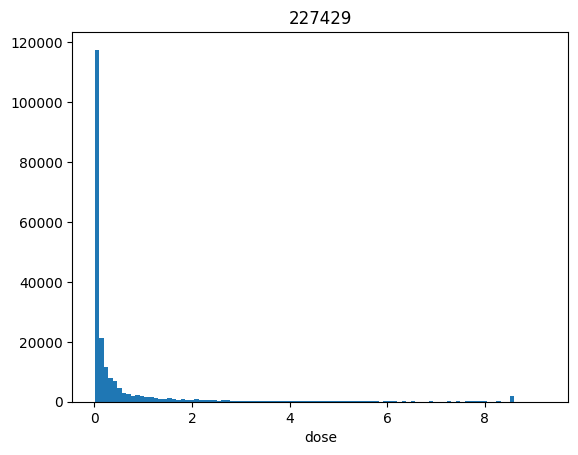

In [147]:
labs = ['227429'] # troponin-T
for lab in labs:
    values = icu_events_df[icu_events_df[lab] > 0][lab]
    print(f"{lab}: median={values.median():.2f}, p25={values.quantile(0.25):.2f}, p75={values.quantile(0.75):.2f}, p90={values.quantile(0.90):.2f}")
    plt.figure()
    plt.hist(values, bins=100)
    plt.title(lab)
    plt.xlabel('dose')
    plt.show()

221794: median=10.03, p25=5.01, p75=20.00, p90=40.00


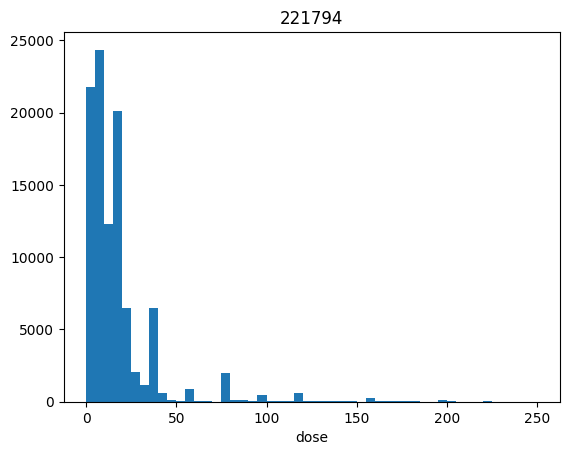

221653: median=17.63, p25=11.10, p75=25.77, p90=34.76


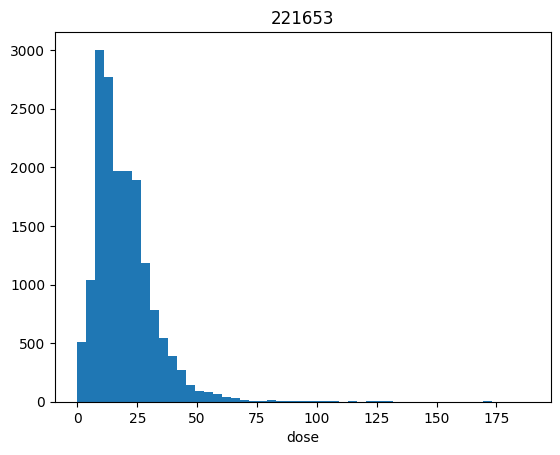

221906: median=0.43, p25=0.21, p75=0.87, p90=1.50


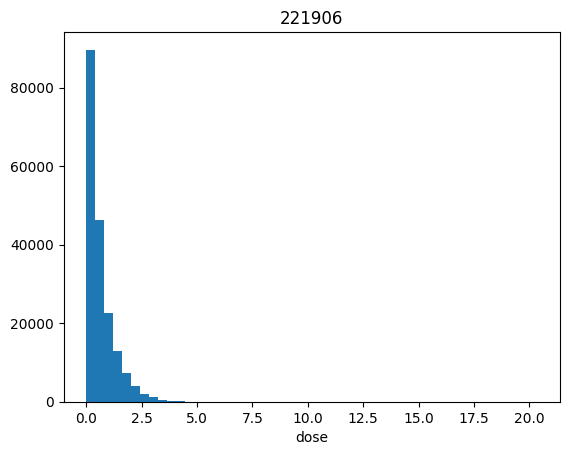

222056: median=4.01, p25=1.95, p75=7.72, p90=12.35


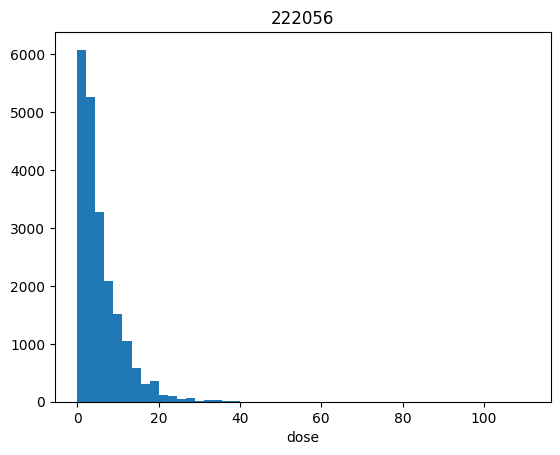

221986: median=1.38, p25=0.92, p75=1.98, p90=2.48


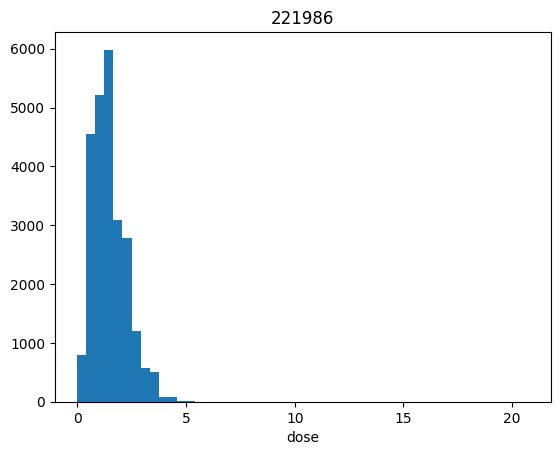

In [60]:
drugs = ['221794', '221653', '221906', '222056', '221986'] # Furosemide, Dobutamine, Norepinephrine, Nitroglycerin, Milrinone
for drug in drugs:
    values = icu_events_df[icu_events_df[drug] > 0][drug]
    print(f"{drug}: median={values.median():.2f}, p25={values.quantile(0.25):.2f}, p75={values.quantile(0.75):.2f}, p90={values.quantile(0.90):.2f}")
    plt.figure()
    plt.hist(values, bins=50)
    plt.title(drug)
    plt.xlabel('dose')
    plt.show()

In [148]:
ts_dataset['Edema'].value_counts()

Edema
0.0    1601864
1.0      16907
Name: count, dtype: int64

In [61]:
test = ts_dataset.copy()

# mask = test['Edema'] == 1.0
# silver_results = test.loc[mask].apply(silver_standard_for_edema, axis=1)

# # Edema=1인 행에만 값 할당
# test.loc[mask, 'subtype_label'] = silver_results['label']
# test.loc[mask, 'cpe_score'] = silver_results['cpe_score']
# test.loc[mask, 'ncpe_score'] = silver_results['ncpe_score']
# test.loc[mask, 'score_diff'] = silver_results['score_diff']

# print(test['subtype_label'].value_counts(dropna=False))

In [63]:
test[mask]['cpe_score'].describe()

count    12411.000000
mean         0.762509
std          1.023254
min          0.000000
25%          0.000000
50%          0.500000
75%          1.000000
max          5.500000
Name: cpe_score, dtype: float64

In [64]:
test[mask]['ncpe_score'].describe()

count    12411.000000
mean         1.102409
std          1.382901
min          0.000000
25%          0.000000
50%          0.500000
75%          1.500000
max          5.750000
Name: ncpe_score, dtype: float64

- 주요 라벨링 분포 지표

In [65]:
analysis_df = test[test["Edema"]==1]
analysis_df = analysis_df[['stay_id', 'hour_slot', 'Edema', 'subtype_label', 'cpe_score', 'ncpe_score', 'score_diff']].reset_index(drop=True)

In [66]:
test.groupby('subtype_label')[['cpe_score','ncpe_score','score_diff']].mean()

,cpe_score,ncpe_score,score_diff
subtype_label,,,
0.0,2.771978,2.792582,-0.020604
1.0,0.439254,2.826765,-2.387511
2.0,3.165109,0.521223,2.643886


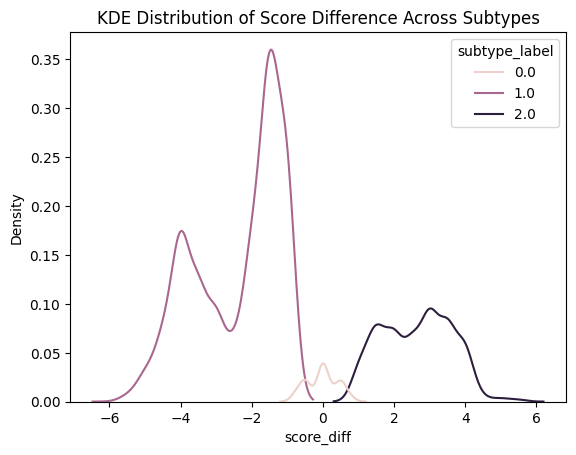

In [67]:
sns.kdeplot(data=test, x="score_diff", hue="subtype_label")
plt.title("KDE Distribution of Score Difference Across Subtypes")
plt.show()

In [68]:
itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")
itemid_df['itemid'] = itemid_df['itemid'].astype(str)

analysis_df = test[(test['Edema'] == 1) & (test['subtype_label'].notna())].copy()

FEATURES = [
    '227446','50963','227445', 'bun_creatinine', '227429',
    'spo2_fio2', '223835', '227456', '223761',
]

def compute_group_stats(df, features):
    rows = []
    for f in features:
        if f not in df.columns:
            continue
        
        valid = df[df[f] != -2]
        
        for label in [0.0, 1.0, 2.0]:
            sub = valid[valid['subtype_label'] == label]
            rows.append({
                "feature": f,
                "label": label,
                "median": sub[f].median(),
                "mean": sub[f].mean(),
                "n": len(sub)
            })
    
    return pd.DataFrame(rows)

stats_df = compute_group_stats(analysis_df, FEATURES)
stats_pivot = stats_df.pivot(index='feature', columns='label', values='median')

stats_pivot = stats_pivot.merge(
    itemid_df[['itemid', 'label']].rename(columns={'itemid': 'feature'}),
    on='feature',
    how='left'
)

stats_pivot = stats_pivot[['feature', 'label'] + [col for col in stats_pivot.columns if col not in ['feature', 'label']]]
stats_pivot

,feature,label,0.0,1.0,2.0
0,223761,Temperature Fahrenheit,36.888889,37.000000,36.888889
1,223835,Inspired O2 Fraction,0.600000,0.600000,0.400000
2,227429,Troponin-T,1.020000,0.070000,0.640000
3,227445,CK-MB,12.166667,5.000000,6.000000
4,227446,Brain Natiuretic Peptide (BNP),6705.000000,1847.000000,6836.000000
5,227456,Albumin,3.000000,2.900000,3.100000
6,50963,NaN,5432.000000,1924.500000,7478.000000
7,bun_creatinine,NaN,23.636364,20.000000,24.226190
8,spo2_fio2,NaN,165.000000,163.333333,240.000000


In [69]:
test.groupby('subtype_label')['score_diff'].describe(percentiles=[.01,.05,.1,.25,.5,.75,.9,.95,.99])

,count,mean,std,min,1%,5%,10%,25%,50%,75%,90%,95%,99%,max
subtype_label,,,,,,,,,,,,,,
0.0,182.0,-0.020604,0.422831,-0.75,-0.75,-0.75,-0.5,-0.50,0.00,0.25,0.5,0.5,0.75,0.75
1.0,3527.0,-2.387511,1.232470,-5.75,-5.00,-4.50,-4.0,-3.50,-2.00,-1.50,-1.0,-1.0,-1.00,-1.00
2.0,1284.0,2.643886,0.971427,1.00,1.00,1.00,1.5,1.75,2.75,3.50,4.0,4.0,5.00,5.50


In [70]:
print("Level 1 Label distritubion")
print(test['Edema'].value_counts(dropna=False))

print("\nLevel 2 Label distritubion")
print(test['subtype_label'].value_counts(dropna=False))

Level 1 Label distritubion
Edema
 NaN    1565474
 0.0      36390
 1.0      12411
-1.0       4496
Name: count, dtype: int64

Level 2 Label distritubion
subtype_label
NaN    1613778
1.0       3527
2.0       1284
0.0        182
Name: count, dtype: int64


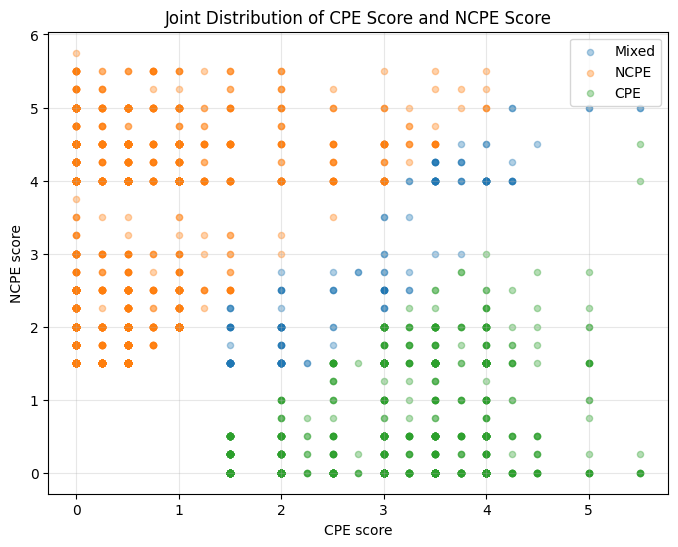

In [71]:
def plot_joint_distribution_scatter(df, label_col='label',
                                    cpe_col='cpe_score',
                                    ncpe_col='ncpe_score'):
    plot_df = df[[label_col, cpe_col, ncpe_col]].dropna().copy()

    label_map = {
        0.0: 'Mixed',
        1.0: 'NCPE',
        2.0: 'CPE'
    }
    plot_df['label_name'] = plot_df[label_col].map(label_map)

    plt.figure(figsize=(8, 6))

    for label_value, label_name in label_map.items():
        sub = plot_df[plot_df[label_col] == label_value]
        if len(sub) == 0:
            continue
        plt.scatter(
            sub[cpe_col],
            sub[ncpe_col],
            alpha=0.35,
            s=20,
            label=label_name
        )

    plt.xlabel('CPE score')
    plt.ylabel('NCPE score')
    plt.title('Joint Distribution of CPE Score and NCPE Score')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_joint_distribution_scatter(test, label_col='subtype_label', cpe_col='cpe_score', ncpe_col='ncpe_score')

In [72]:
def intermediate_progression_analysis(df, stay_col='stay_id', time_col='hour_slot', label_col='label', intermediate_label=0.0):
    temp = df[[stay_col, time_col, label_col]].dropna().copy()
    temp = temp.sort_values([stay_col, time_col])

    results = []

    for stay_id, sub in temp.groupby(stay_col):
        sub = sub.sort_values(time_col)
        labels = sub[label_col].tolist()

        if intermediate_label not in labels:
            continue

        first_intermediate_idx = labels.index(intermediate_label)
        later_labels = labels[first_intermediate_idx + 1:]

        progressed_to = 'stayed_or_unknown'
        if 2.0 in later_labels:
            progressed_to = 'to_CPE'
        elif 1.0 in later_labels:
            progressed_to = 'to_NCPE'

        results.append({
            stay_col: stay_id,
            'progression': progressed_to
        })

    result_df = pd.DataFrame(results)

    summary = (
        result_df['progression']
        .value_counts(dropna=False)
        .reset_index()
    )
    summary.columns = ['progression', 'count']
    summary['proportion'] = summary['count'] / summary['count'].sum()

    return result_df, summary

progression_df, progression_summary = intermediate_progression_analysis(test, label_col='subtype_label')
progression_summary

,progression,count,proportion
0,to_CPE,72,0.496552
1,stayed_or_unknown,55,0.379310
2,to_NCPE,18,0.124138


In [73]:
progression_df

,stay_id,progression
0,30109454,stayed_or_unknown
1,30129989,to_NCPE
2,30340121,to_NCPE
3,30397772,stayed_or_unknown
4,30509159,to_NCPE
...,...,...
140,39793956,to_CPE
141,39820699,to_CPE
142,39865725,to_CPE
143,39902669,to_CPE


---

## 데이터 최종 전처리 부분

In [62]:
labeled_ts_dataset = test.copy()

In [63]:
labeled_ts_dataset.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices'],
      dtype='object')

In [64]:
key_id_icu = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/key_id_icu.ftr")
key_id_icu = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]

patient_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/core/parquet/patients.parquet")
patient_df = patient_df[['subject_id', 'gender']]

df_weight = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/df_weight.ftr')
df_weight = df_weight.rename(columns={'valuenum':'weight'})
df_weight = df_weight.drop(columns=['charttime', 'stay_id', 'hadm_id'])
subject_weight = df_weight.groupby('subject_id')['weight'].mean().reset_index()

demo_df = key_id_icu.merge(patient_df, how='left', on=['subject_id'])
demo_df = demo_df.merge(subject_weight, how='left', on=['subject_id'])
demo_df

,subject_id,hadm_id,stay_id,gender,weight
0,10001884,26184834.0,37510196.0,F,65.000000
1,10002428,23473524.0,35479615.0,F,46.340934
2,10002428,28662225.0,33987268.0,F,46.340934
3,10002428,28662225.0,38875437.0,F,46.340934
4,10003400,20214994.0,32128372.0,F,95.521724
...,...,...,...,...,...
14141,19998330,24096838.0,33428243.0,F,78.670588
14142,19998843,24842066.0,30988867.0,M,72.823529
14143,19999287,20175828.0,35165301.0,F,86.850725
14144,19999442,26785317.0,32336619.0,M,107.393662


In [65]:
# 8개의 subject_id만 weight가 결측임. 
demo_df['weight'].isnull().sum()

# 따라서 그냥 성별별 median 값으로 채우는 것을 선택함.
gender_median = demo_df.groupby('gender')['weight'].median()

# M, F만 확실하다면 get() 없이 바로 접근
print(f"남성 체중 중앙값: {gender_median['M']}")
print(f"여성 체중 중앙값: {gender_median['F']}")

# 결측치 채우기
demo_df['weight'] = demo_df['weight'].fillna(demo_df['gender'].map(gender_median))

labeled_ts_dataset = labeled_ts_dataset.merge(demo_df[['stay_id', 'weight']], how='left', on=['stay_id'])

# Crystalloid / Patient weight
labeled_ts_dataset['cryst_weight'] = labeled_ts_dataset['fluid_cyst'] / labeled_ts_dataset['weight']

남성 체중 중앙값: 83.14565217391304
여성 체중 중앙값: 70.3747663551402


In [66]:
final_ts_df = labeled_ts_dataset.copy()

In [67]:
final_ts_df.columns

Index(['hadm_id', 'stay_id', 'hour_slot', '50963', '220045', '220179',
       '220180', '220210', '220277', '220546', '220615', '220645', '223761',
       '223835', '225624', '225668', '227073', '227429', '227442', '227445',
       '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
       '221749', '221794', '221906', '221986', '222051', '222056', '225168',
       '225974', 'fluid_alb', 'fluid_cyst', '225402', '225794', 'urine',
       'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema',
       'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity',
       'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia',
       'Pneumothorax', 'Support Devices', 'weight', 'cryst_weight'],
      dtype='object')

In [68]:
value_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220277', '220546', '220615', '220645', '223761',
    '223835', '225624', '225668', '227073', '227429', '227442', '227445',
    '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
    '221749', '221794', '221906', '221986', '222051', '222056', '225168',
    '225974', 'fluid_alb', 'cryst_weight', '225402', '225794', 'urine', 
]

In [69]:
label_cols = [
    'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 
    'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices'
]

In [70]:
df_masks = final_ts_df[['hadm_id', 'stay_id', 'hour_slot'] + value_cols + label_cols]

In [71]:
df_masks = df_masks.merge(key_id_icu, how='left', on=['hadm_id', 'stay_id'])
df_masks = df_masks.sort_values(by=['subject_id', 'hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
df_masks

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,cryst_weight,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,subject_id
0,26184834,37510196,0,-2.0,49.000000,173.5,30.5,10.000000,98.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,14.336044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.922689,0.0,0.0,0.000000,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
1,26184834,37510196,1,-2.0,72.000000,102.0,63.0,20.000000,100.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,19.512196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.489540,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
2,26184834,37510196,2,-2.0,70.666667,101.5,69.0,17.666667,95.0,18.4,1.1,135.5,35.400000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,190.0,27.272727,0.0,22.905149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.722716,1.0,0.0,92.048611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
3,26184834,37510196,3,-2.0,71.000000,102.0,71.0,20.000000,100.0,18.4,1.1,135.5,35.800000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,200.0,27.272727,0.0,29.530504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.921432,1.0,0.0,215.296022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
4,26184834,37510196,4,-2.0,71.000000,138.0,76.0,20.000000,98.0,18.4,1.1,135.5,36.300000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,196.0,27.272727,0.0,21.831458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.573820,0.0,0.0,123.782818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618767,23865745,36195440,43,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618768,23865745,36195440,44,-2.0,93.000000,163.0,120.0,20.000000,100.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,303.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618769,23865745,36195440,45,-2.0,92.000000,163.0,120.0,23.000000,100.0,11.6,1.2,147.0,37.833333,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.679778,0.0,0.0,21.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987


In [72]:
from preprocess.scaling_functions import (
    feature_specific_scaling_fit,
    feature_specific_scaling_transform,
    create_precise_flags,
    save_scaling_stats,
    load_scaling_stats
)

# from preprocess.split_functions import split_by_stay_id
from preprocess.split_functions import split_by_subject_stratified

In [73]:
itemid_df = pd.read_parquet("/home/DAHS1/gangmin/my_research/data/mimic-iv/icu/parquet/d_items.parquet")

# procedure는 정규화 대상에서 제외해야 함.
no_proc_feature_cols = [
    '50963', '220045', '220179',
    '220180', '220210', '220277', '220546', '220615', '220645', '223761',
    '223835', '225624', '225668', '227073', '227429', '227442', '227445',
    '227446', '227456', 'spo2_fio2', 'bun_creatinine', '221653', '221662',
    '221749', '221794', '221906', '221986', '222051', '222056', '225168',
    '225974', 'fluid_alb', 'cryst_weight', 'urine', 
]

# 파생변수나 lab은 안 보임.
itemid_df['itemid'] = itemid_df['itemid'].astype(str)
itemid_df[itemid_df['itemid'].isin(no_proc_feature_cols)].reset_index(drop=True)

,itemid,label,abbreviation,linksto,category,unitname,param_type,lownormalvalue,highnormalvalue
0,220045,Heart Rate,HR,chartevents,Routine Vital Signs,bpm,Numeric,NaN,NaN
1,220179,Non Invasive Blood Pressure systolic,NBPs,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
2,220180,Non Invasive Blood Pressure diastolic,NBPd,chartevents,Routine Vital Signs,mmHg,Numeric,NaN,NaN
3,220210,Respiratory Rate,RR,chartevents,Respiratory,insp/min,Numeric,NaN,NaN
4,220277,O2 saturation pulseoxymetry,SpO2,chartevents,Respiratory,%,Numeric,NaN,NaN
5,220546,WBC,WBC,chartevents,Labs,None,Numeric,NaN,NaN
6,220615,Creatinine (serum),Creatinine (serum),chartevents,Labs,None,Numeric,NaN,NaN
7,220645,Sodium (serum),Sodium (serum),chartevents,Labs,None,Numeric,NaN,NaN
8,221653,Dobutamine,Dobutamine,inputevents,Medications,mg,Solution,NaN,NaN
9,221662,Dopamine,Dopamine,inputevents,Medications,mg,Solution,NaN,NaN


In [74]:
df_masks.to_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/df_masks_20260428_all_label.ftr')

---

In [ ]:
# df_masks = pd.read_feather('/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/df_masks_20260428.ftr')

In [76]:
df_masks

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220277,220546,220615,220645,223761,223835,225624,225668,227073,227429,227442,227445,227446,227456,spo2_fio2,bun_creatinine,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,fluid_alb,cryst_weight,225402,225794,urine,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,subject_id
0,26184834,37510196,0,-2.0,49.000000,173.5,30.5,10.000000,98.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,14.336044,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.922689,0.0,0.0,0.000000,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
1,26184834,37510196,1,-2.0,72.000000,102.0,63.0,20.000000,100.0,12.2,1.1,130.0,-2.000000,-2.0,27.0,1.7,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,24.545455,0.0,19.512196,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.489540,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
2,26184834,37510196,2,-2.0,70.666667,101.5,69.0,17.666667,95.0,18.4,1.1,135.5,35.400000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,190.0,27.272727,0.0,22.905149,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.722716,1.0,0.0,92.048611,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
3,26184834,37510196,3,-2.0,71.000000,102.0,71.0,20.000000,100.0,18.4,1.1,135.5,35.800000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,200.0,27.272727,0.0,29.530504,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.921432,1.0,0.0,215.296022,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
4,26184834,37510196,4,-2.0,71.000000,138.0,76.0,20.000000,98.0,18.4,1.1,135.5,36.300000,0.5,30.0,1.5,11.0,0.08,3.975,14.0,-2.0,3.5,196.0,27.272727,0.0,21.831458,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.573820,0.0,0.0,123.782818,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10001884
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,23865745,36195440,42,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618767,23865745,36195440,43,-2.0,98.000000,152.0,92.0,22.000000,97.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618768,23865745,36195440,44,-2.0,93.000000,163.0,120.0,20.000000,100.0,11.6,1.2,147.0,37.000000,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,303.333333,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987
1618769,23865745,36195440,45,-2.0,92.000000,163.0,120.0,23.000000,100.0,11.6,1.2,147.0,37.833333,-2.0,22.0,-2.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,18.333333,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.679778,0.0,0.0,21.666667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,19999987


In [75]:
ones = df_masks[label_cols].sum()
zeros = len(df_masks) - ones

label_summary = pd.DataFrame({'Positive label': ones})
label_summary.sort_values(by="Positive label", ascending=False)

,Positive label
Support Devices,35371.0
Pleural Effusion,23364.0
Atelectasis,20142.0
Cardiomegaly,19451.0
Lung Opacity,18513.0
Edema,16907.0
Pneumonia,8809.0
Enlarged Cardiomediastinum,7053.0
No Finding,6751.0
Consolidation,6314.0


In [77]:
vital_cols = ['220045', '220179', '220180', '220210', '223761', 'spo2_fio2', '220277', '223835']
input_cols = ['221653', '221662', '221749', '221794', '221906', '221986', '222051', '222056', '225168', '225974']
urine_fluid_cols = ['urine', 'fluid_alb', 'cryst_weight']
lab_cols = ['225624', '220645', '227073', '227429', '227442', '227445', '227446', '227456', '50963', '220546', '220615', '225668', 'bun_creatinine']
proc_cols = ['225402', '225794']

meta_cols = ['subject_id', 'hadm_id', 'stay_id', 'hour_slot', 'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum', 'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding', 'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax', 'Support Devices']

In [78]:
selected_cols = meta_cols + vital_cols + lab_cols + urine_fluid_cols + proc_cols

df_masks = df_masks[selected_cols]

In [79]:
df_masks

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220179,220180,220210,223761,spo2_fio2,220277,223835,225624,220645,227073,227429,227442,227445,227446,227456,50963,220546,220615,225668,bun_creatinine,urine,fluid_alb,cryst_weight,225402,225794
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,49.000000,173.5,30.5,10.000000,-2.000000,-2.0,98.0,-2.0,27.0,130.0,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,12.2,1.1,1.7,24.545455,0.000000,0.0,1.922689,0.0,0.0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,72.000000,102.0,63.0,20.000000,-2.000000,-2.0,100.0,-2.0,27.0,130.0,17.0,0.05,4.500,20.0,-2.0,-2.0,-2.0,12.2,1.1,1.7,24.545455,0.000000,0.0,0.489540,0.0,0.0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.666667,101.5,69.0,17.666667,35.400000,190.0,95.0,0.5,30.0,135.5,11.0,0.08,3.975,14.0,-2.0,3.5,-2.0,18.4,1.1,1.5,27.272727,92.048611,0.0,0.722716,1.0,0.0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,102.0,71.0,20.000000,35.800000,200.0,100.0,0.5,30.0,135.5,11.0,0.08,3.975,14.0,-2.0,3.5,-2.0,18.4,1.1,1.5,27.272727,215.296022,0.0,3.921432,1.0,0.0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71.000000,138.0,76.0,20.000000,36.300000,196.0,98.0,0.5,30.0,135.5,11.0,0.08,3.975,14.0,-2.0,3.5,-2.0,18.4,1.1,1.5,27.272727,123.782818,0.0,0.573820,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000,152.0,92.0,22.000000,37.000000,-2.0,97.0,-2.0,22.0,147.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,0.000000,0.0,0.000000,0.0,0.0
1618767,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.000000,152.0,92.0,22.000000,37.000000,-2.0,97.0,-2.0,22.0,147.0,11.0,1.13,4.100,38.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,0.000000,0.0,0.000000,0.0,0.0
1618768,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,93.000000,163.0,120.0,20.000000,37.000000,-2.0,100.0,-2.0,22.0,147.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,303.333333,0.0,0.000000,0.0,0.0
1618769,19999987,23865745,36195440,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,92.000000,163.0,120.0,23.000000,37.833333,-2.0,100.0,-2.0,22.0,147.0,11.0,-2.00,4.100,-2.0,-2.0,-2.0,-2.0,11.6,1.2,-2.0,18.333333,21.666667,0.0,2.679778,0.0,0.0


In [80]:
# 1. Split 먼저 수행 (patient-level stratified)
print("\n" + "="*80)
print("STEP 1: Patient-level Stratified Split")
print("="*80)

# train_ts_raw, val_ts_raw, test_ts_raw = split_by_stay_id(
#     df_masks,
#     train_ratio=0.7,
#     val_ratio=0.15,
#     random_seed=42
# )

train_ts_raw, val_ts_raw, test_ts_raw = split_by_subject_stratified(
    df_masks,
    train_ratio=0.8,
    val_ratio=0.1,
    random_seed=42
)


STEP 1: Patient-level Stratified Split

[Dataset Split] Subject-level random split (no label stratification):
  Train: 8,684 subjects / 1,289,557 rows  (80.0%)
  Val:   1,085 subjects / 160,744 rows  (10.0%)
  Test:  1,086 subjects / 168,470 rows  (10.0%)
  [OK] No subject overlap between splits



In [81]:
# 2. Scaling with Train Statistics
print("\n" + "="*80)
print("STEP 2: Scaling with Train Statistics")
print("="*80)

train_scaled, scaling_stats = feature_specific_scaling_fit(
    train_ts_raw,
    lab_cols=lab_cols,
    input_urine_cols=urine_fluid_cols,
    vital_cols=vital_cols,
    sentinel=-2
)

print(f"✅ Train set scaled. Shape: {train_scaled.shape}")
print(f"✅ Scaling statistics computed for {len(scaling_stats)} columns")


STEP 2: Scaling with Train Statistics
✅ Train set scaled. Shape: (1289557, 44)
✅ Scaling statistics computed for 24 columns


In [82]:
train_scaled

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220179,220180,220210,223761,spo2_fio2,220277,223835,225624,220645,227073,227429,227442,227445,227446,227456,50963,220546,220615,225668,bun_creatinine,urine,fluid_alb,cryst_weight,225402,225794
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.131779,2.433486,-2.150174,-1.801531,-2.000000,-2.000000,0.335223,-2.000000,0.131035,-1.653103,0.729899,-0.489188,0.862212,1.052226,-2.0,-2.000000,-2.0,0.227274,-0.181775,0.071726,0.234776,0.000000,0.0,0.226195,0.0,0.0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.851027,-0.813465,-0.064900,-0.089758,-2.000000,-2.000000,0.900309,-2.000000,0.131035,-1.653103,0.729899,-0.489188,0.862212,1.052226,-2.0,-2.000000,-2.0,0.227274,-0.181775,0.071726,0.234776,0.000000,0.0,-0.377140,0.0,0.0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.925273,-0.836171,0.320074,-0.489172,-2.835093,-0.618411,-0.512406,0.215667,0.278892,-0.588956,-0.917397,-0.427989,-0.077486,0.724027,-2.0,0.848077,-2.0,1.007660,-0.181775,-0.148898,0.431466,-0.067542,0.0,-0.278976,1.0,0.0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,-0.813465,0.448398,-0.089758,-2.130897,-0.435984,0.900309,0.215667,0.278892,-0.588956,-0.917397,-0.427989,-0.077486,0.724027,-2.0,0.848077,-2.0,1.007660,-0.181775,-0.148898,0.431466,1.014560,0.0,1.067636,1.0,0.0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,0.821363,0.769210,-0.089758,-1.250652,-0.508955,0.335223,0.215667,0.278892,-0.588956,-0.917397,-0.427989,-0.077486,0.724027,-2.0,0.848077,-2.0,1.007660,-0.181775,-0.148898,0.431466,0.211082,0.0,-0.341659,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.457130,1.795806,0.252596,-0.018308,-2.000000,0.052680,-2.000000,-0.154720,1.503969,-0.917397,1.047443,0.154951,1.656045,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,0.000000,0.0,0.000000,0.0,0.0
1618767,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.457130,1.795806,0.252596,-0.018308,-2.000000,0.052680,-2.000000,-0.154720,1.503969,-0.917397,1.047443,0.154951,1.656045,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,0.000000,0.0,0.000000,0.0,0.0
1618768,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.318355,1.956661,3.592350,-0.089758,-0.018308,-2.000000,0.900309,-2.000000,-0.154720,1.503969,-0.917397,-2.000000,0.154951,-2.000000,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,1.787521,0.0,0.000000,0.0,0.0
1618769,19999987,23865745,36195440,45,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.262670,1.956661,3.592350,0.423773,1.448767,-2.000000,0.900309,-2.000000,-0.154720,1.503969,-0.917397,-2.000000,0.154951,-2.000000,-2.0,-2.000000,-2.0,0.132992,-0.071407,-2.000000,-0.305491,-0.685490,0.0,0.544918,0.0,0.0


In [182]:
train_scaled.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hour_slot', 'Atelectasis',
       'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum',
       'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding',
       'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax',
       'Support Devices', '220045', '220179', '220180', '220210', '223761',
       'spo2_fio2', '220277', '223835', '225624', '220645', '227073', '227429',
       '227442', '227445', '227446', '227456', '50963', '220546', '220615',
       '225668', 'bun_creatinine', 'urine', 'fluid_alb', 'cryst_weight',
       '225402', '225794'],
      dtype='object')

In [84]:
len(train_scaled.columns)

44

In [83]:
print("\nTransforming val set with train statistics")
val_scaled = feature_specific_scaling_transform(val_ts_raw, scaling_stats, sentinel=-2)
print(f"✅ Val set scaled. Shape: {val_scaled.shape}")

print("\nTransforming test set with train statistics")
test_scaled = feature_specific_scaling_transform(test_ts_raw, scaling_stats, sentinel=-2)
print(f"✅ Test set scaled. Shape: {test_scaled.shape}")


Transforming val set with train statistics
✅ Val set scaled. Shape: (160744, 44)

Transforming test set with train statistics
✅ Test set scaled. Shape: (168470, 44)


In [85]:
# 3. Create Precise Flags
print("\n" + "="*80)
print("STEP 3: Creating Precise Flags")
print("="*80)

print("Creating flags for train set")
train_with_flags = create_precise_flags(
    df_raw=train_ts_raw,
    df_scaled=train_scaled,
    io_cols=urine_fluid_cols,
    procedure_cols=proc_cols,
    meta_cols=meta_cols,
    sentinel=-2
)

print(f"✅ Train with flags. Shape: {train_with_flags.shape}")
print(f"   Columns: {len(train_with_flags.columns)} (original: {len(train_scaled.columns)})")


STEP 3: Creating Precise Flags
Creating flags for train set
✅ Train with flags. Shape: (1289557, 65)
   Columns: 65 (original: 44)


In [86]:
train_with_flags

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220045_flag,220179,220179_flag,220180,220180_flag,220210,220210_flag,223761,223761_flag,spo2_fio2,spo2_fio2_flag,220277,220277_flag,223835,223835_flag,225624,225624_flag,220645,220645_flag,227073,227073_flag,227429,227429_flag,227442,227442_flag,227445,227445_flag,227446,227446_flag,227456,227456_flag,50963,50963_flag,220546,220546_flag,220615,220615_flag,225668,225668_flag,bun_creatinine,bun_creatinine_flag,urine,fluid_alb,cryst_weight,225402,225794
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.131779,1.0,2.433486,1.0,-2.150174,1.0,-1.801531,1.0,0.000000,0.0,0.000000,0.0,0.335223,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,0.226195,0.0,0.0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.851027,1.0,-0.813465,1.0,-0.064900,1.0,-0.089758,1.0,0.000000,0.0,0.000000,0.0,0.900309,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,-0.377140,0.0,0.0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.925273,1.0,-0.836171,1.0,0.320074,1.0,-0.489172,1.0,-2.835093,1.0,-0.618411,1.0,-0.512406,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,-0.067542,0.0,-0.278976,1.0,0.0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,-0.813465,1.0,0.448398,1.0,-0.089758,1.0,-2.130897,1.0,-0.435984,1.0,0.900309,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,1.014560,0.0,1.067636,1.0,0.0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,0.821363,1.0,0.769210,1.0,-0.089758,1.0,-1.250652,1.0,-0.508955,1.0,0.335223,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,0.211082,0.0,-0.341659,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1618766,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.0,1.457130,1.0,1.795806,1.0,0.252596,1.0,-0.018308,1.0,0.000000,0.0,0.052680,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,1.047443,1.0,0.154951,1.0,1.656045,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.132992,1.0,-0.071407,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0
1618767,19999987,23865745,36195440,43,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.0,1.457130,1.0,1.795806,1.0,0.252596,1.0,-0.018308,1.0,0.000000,0.0,0.052680,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,1.047443,1.0,0.154951,1.0,1.656045,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.132992,1.0,-0.071407,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0
1618768,19999987,23865745,36195440,44,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.318355,1.0,1.956661,1.0,3.592350,1.0,-0.089758,1.0,-0.018308,1.0,0.000000,0.0,0.900309,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,0.000000,0.0,0.154951,1.0,0.000000,0.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.1329

In [87]:
len(train_with_flags.columns) - len(meta_cols)

47

In [88]:
train_with_flags.columns

Index(['subject_id', 'hadm_id', 'stay_id', 'hour_slot', 'Atelectasis',
       'Cardiomegaly', 'Consolidation', 'Edema', 'Enlarged Cardiomediastinum',
       'Fracture', 'Lung Lesion', 'Lung Opacity', 'No Finding',
       'Pleural Effusion', 'Pleural Other', 'Pneumonia', 'Pneumothorax',
       'Support Devices', '220045', '220045_flag', '220179', '220179_flag',
       '220180', '220180_flag', '220210', '220210_flag', '223761',
       '223761_flag', 'spo2_fio2', 'spo2_fio2_flag', '220277', '220277_flag',
       '223835', '223835_flag', '225624', '225624_flag', '220645',
       '220645_flag', '227073', '227073_flag', '227429', '227429_flag',
       '227442', '227442_flag', '227445', '227445_flag', '227446',
       '227446_flag', '227456', '227456_flag', '50963', '50963_flag', '220546',
       '220546_flag', '220615', '220615_flag', '225668', '225668_flag',
       'bun_creatinine', 'bun_creatinine_flag', 'urine', 'fluid_alb',
       'cryst_weight', '225402', '225794'],
      dtype='object'

In [89]:
print("\nCreating flags for val set...")
val_with_flags = create_precise_flags(
    df_raw=val_ts_raw,
    df_scaled=val_scaled,
    io_cols=urine_fluid_cols,
    procedure_cols=proc_cols,
    meta_cols=meta_cols,
    sentinel=-2
)
print(f"✅ Val with flags. Shape: {val_with_flags.shape}")

print("\nCreating flags for test set...")
test_with_flags = create_precise_flags(
    df_raw=test_ts_raw,
    df_scaled=test_scaled,
    io_cols=urine_fluid_cols,
    procedure_cols=proc_cols,
    meta_cols=meta_cols,
    sentinel=-2
)
print(f"✅ Test with flags. Shape: {test_with_flags.shape}")


Creating flags for val set...
✅ Val with flags. Shape: (160744, 65)

Creating flags for test set...
✅ Test with flags. Shape: (168470, 65)


In [32]:
# output_dir = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/3rd_preprocessed_data/'

# train_with_flags.to_feather(output_dir + 'train_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}train_multimodal_20260428_ssl.ftr")

# val_with_flags.to_feather(output_dir + 'val_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}val_multimodal_20260428_ssl.ftr")

# test_with_flags.to_feather(output_dir + 'test_multimodal_20260428_ssl.ftr')
# print(f"✅ Saved: {output_dir}test_multimodal_20260428_ssl.ftr")

In [90]:
# 4. 이미지/텍스트/clinical_prompt left join
print("\n" + "="*80)
print("STEP 3: Joining Image/Text/Clinical Prompt Data")
print("="*80)

# 이미지/텍스트 데이터 로드
img_df = pd.read_feather(root_dir + 'src/test/total_cxr_df_5days_20260316.ftr')
text_df = pd.read_feather(root_dir + 'src/test/final_text_df_20260128.ftr')
clinical_prompt_df = pd.read_feather(root_dir + "clinical_multimodal_learning/data/clinical_prompt_df.ftr")

print("Merging train set")
train_final = (train_with_flags
    .merge(img_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(text_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(clinical_prompt_df[['hadm_id', 'stay_id', 'hour_slot', 'clinical_prompt', 'prompt_id']], 
    on=['hadm_id', 'stay_id', 'hour_slot'], how='left')
)
print(f"✅ Train final shape: {train_final.shape}")


STEP 3: Joining Image/Text/Clinical Prompt Data


Merging train set
✅ Train final shape: (1289557, 71)


In [91]:
print("Merging val set")
val_final = (val_with_flags
    .merge(img_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(text_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(clinical_prompt_df[['hadm_id', 'stay_id', 'hour_slot', 'clinical_prompt', 'prompt_id']], 
    on=['hadm_id', 'stay_id', 'hour_slot'], how='left')
)
print(f"✅ Val final shape: {val_final.shape}")

print("Merging test set")
test_final = (test_with_flags
    .merge(img_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(text_df, on=['stay_id', 'hour_slot'], how='left')
    .merge(clinical_prompt_df[['hadm_id', 'stay_id', 'hour_slot', 'clinical_prompt', 'prompt_id']], 
    on=['hadm_id', 'stay_id', 'hour_slot'], how='left')
)
print(f"✅ Test final shape: {test_final.shape}")

Merging val set
✅ Val final shape: (160744, 71)
Merging test set
✅ Test final shape: (168470, 71)


In [92]:
print("\n" + "="*80)
print("Saving Processed Data")
print("="*80)

output_dir = '/home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/'

train_final.to_feather(output_dir + 'train_multimodal_20260428_alllabel.ftr')
print(f"✅ Saved: {output_dir}train_multimodal_20260428_alllabel.ftr")

val_final.to_feather(output_dir + 'val_multimodal_20260428_alllabel.ftr')
print(f"✅ Saved: {output_dir}val_multimodal_20260428_alllabel.ftr")

test_final.to_feather(output_dir + 'test_multimodal_20260428_alllabel.ftr')
print(f"✅ Saved: {output_dir}test_multimodal_20260428_alllabel.ftr")

save_scaling_stats(scaling_stats, output_dir + 'scaling_stats_20260428_alllabel.pkl')

print("\n" + "="*80)
print("✅ ALL PREPROCESSING COMPLETED!")
print("="*80)
print("\n📊 Data Summary:")
print(f"  Train: {len(train_final):,} rows from {train_final['stay_id'].nunique():,} patients")
print(f"  Val:   {len(val_final):,} rows from {val_final['stay_id'].nunique():,} patients")
print(f"  Test:  {len(test_final):,} rows from {test_final['stay_id'].nunique():,} patients")
print(f"\n  Total columns: {len(train_final.columns)}")
print(f"  Feature columns (with flags): {len([c for c in train_final.columns if '_flag' in c or c not in meta_cols])}")



Saving Processed Data
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/train_multimodal_20260428_alllabel.ftr
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/val_multimodal_20260428_alllabel.ftr
✅ Saved: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/test_multimodal_20260428_alllabel.ftr
✅ Scaling statistics saved to: /home/DAHS1/gangmin/my_research/clinical_multimodal_learning/data/2rd_preprocessed_data/processed/scaling_stats_20260428_alllabel.pkl

✅ ALL PREPROCESSING COMPLETED!

📊 Data Summary:
  Train: 1,289,557 rows from 11,322 patients
  Val:   160,744 rows from 1,414 patients
  Test:  168,470 rows from 1,410 patients

  Total columns: 71
  Feature columns (with flags): 53


In [93]:
train_final

,subject_id,hadm_id,stay_id,hour_slot,Atelectasis,Cardiomegaly,Consolidation,Edema,Enlarged Cardiomediastinum,Fracture,Lung Lesion,Lung Opacity,No Finding,Pleural Effusion,Pleural Other,Pneumonia,Pneumothorax,Support Devices,220045,220045_flag,220179,220179_flag,220180,220180_flag,220210,220210_flag,223761,223761_flag,spo2_fio2,spo2_fio2_flag,220277,220277_flag,223835,223835_flag,225624,225624_flag,220645,220645_flag,227073,227073_flag,227429,227429_flag,227442,227442_flag,227445,227445_flag,227446,227446_flag,227456,227456_flag,50963,50963_flag,220546,220546_flag,220615,220615_flag,225668,225668_flag,bun_creatinine,bun_creatinine_flag,urine,fluid_alb,cryst_weight,225402,225794,cxr_flag,hash_path,text_flag,tokenized_text,clinical_prompt,prompt_id
0,10001884,26184834,37510196,0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-2.131779,1.0,2.433486,1.0,-2.150174,1.0,-1.801531,1.0,0.000000,0.0,0.000000,0.0,0.335223,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,0.226195,0.0,0.0,1.0,286dc12965a39fe9508c988d4dc042d7.pt,1.0,"{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1,...","Demographics: 68-year-old female, black/africa...",0
1,10001884,26184834,37510196,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.851027,1.0,-0.813465,1.0,-0.064900,1.0,-0.089758,1.0,0.000000,0.0,0.000000,0.0,0.900309,1.0,0.000000,0.0,0.131035,1.0,-1.653103,1.0,0.729899,1.0,-0.489188,1.0,0.862212,1.0,1.052226,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.227274,1.0,-0.181775,1.0,0.071726,1.0,0.234776,1.0,0.000000,0.0,-0.377140,0.0,0.0,0.0,None,0.0,"{'attention_mask': [], 'input_ids': []}","Demographics: 68-year-old female, black/africa...",0
2,10001884,26184834,37510196,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.925273,1.0,-0.836171,1.0,0.320074,1.0,-0.489172,1.0,-2.835093,1.0,-0.618411,1.0,-0.512406,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,-0.067542,0.0,-0.278976,1.0,0.0,0.0,None,1.0,"{'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1,...","Demographics: 68-year-old female, black/africa...",0
3,10001884,26184834,37510196,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,-0.813465,1.0,0.448398,1.0,-0.089758,1.0,-2.130897,1.0,-0.435984,1.0,0.900309,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,1.014560,0.0,1.067636,1.0,0.0,0.0,None,0.0,"{'attention_mask': [], 'input_ids': []}","Demographics: 68-year-old female, black/africa...",0
4,10001884,26184834,37510196,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.906712,1.0,0.821363,1.0,0.769210,1.0,-0.089758,1.0,-1.250652,1.0,-0.508955,1.0,0.335223,1.0,0.215667,1.0,0.278892,1.0,-0.588956,1.0,-0.917397,1.0,-0.427989,1.0,-0.077486,1.0,0.724027,1.0,0.0,0.0,0.848077,1.0,0.0,0.0,1.007660,1.0,-0.181775,1.0,-0.148898,1.0,0.431466,1.0,0.211082,0.0,-0.341659,0.0,0.0,0.0,None,0.0,"{'attention_mask': [], 'input_ids': []}","Demographics: 68-year-old female, black/africa...",0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1289552,19999987,23865745,36195440,42,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.596779,1.0,1.457130,1.0,1.795806,1.0,0.252596,1.0,-0.018308,1.0,0.000000,0.0,0.052680,1.0,0.000000,0.0,-0.154720,1.0,1.503969,1.0,-0.917397,1.0,1.047443,1.0,0.154951,1.0,1.656045,1.0,0.0,0.0,0.000000,0.0,0.0,0.0,0.132992,1.0,-0.071407,1.0,0.000000,0.0,-0.305491,1.0,0.000000,0.0,0.000000,0.0,0.0,0.0,None,0.0,"{'a

In [ ]:
train_final['Edema'].value_counts(dropna=False) 

Edema
 NaN    1090172
 0.0      25452
 1.0       8623
-1.0       3100
Name: count, dtype: int64

In [ ]:
train_final['subtype_label'].value_counts(dropna=False) 

subtype_label
NaN    1123860
1.0       2441
2.0        919
0.0        127
Name: count, dtype: int64

In [ ]:
train_final.columns

Index(['hadm_id', 'stay_id', 'hour_slot', 'Edema', 'subtype_label', '220045',
       '220045_flag', '220179', '220179_flag', '220180', '220180_flag',
       '220210', '220210_flag', '223761', '223761_flag', 'spo2_fio2',
       'spo2_fio2_flag', '220277', '220277_flag', '223835', '223835_flag',
       '225624', '225624_flag', '220645', '220645_flag', '227073',
       '227073_flag', '227429', '227429_flag', '227442', '227442_flag',
       '227445', '227445_flag', '227446', '227446_flag', '227456',
       '227456_flag', '50963', '50963_flag', '220546', '220546_flag', '220615',
       '220615_flag', '225668', '225668_flag', 'bun_creatinine',
       'bun_creatinine_flag', 'urine', 'urine_flag', 'fluid_alb',
       'fluid_alb_flag', 'cryst_weight', 'cryst_weight_flag', '225402',
       '225794', 'cxr_flag', 'hash_path', 'text_flag', 'tokenized_text',
       'clinical_prompt', 'prompt_id'],
      dtype='object')

In [ ]:
len(train_final.columns)

61

---

### Old codes

In [ ]:
df_features[(df_features['subtype_label'].isnull()) & (df_features['score_diff_normalized']>0)]

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
741,20013839,38119074,22,-2.0,1.154925,0.391933,0.582431,0.258082,0.786875,0.001563,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.680157,1.0,NaN,0.0,0.388889
742,20013839,38119074,23,-2.0,0.765379,0.568048,0.838801,0.428751,0.786875,0.001563,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.333078,1.0,NaN,0.0,0.388889
743,20013839,38119074,24,-2.0,0.431483,-0.180441,0.197876,-0.936605,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.138667,1.0,NaN,0.0,0.388889
744,20013839,38119074,25,-2.0,1.600121,-0.224469,-0.314865,0.599421,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.318056,1.0,NaN,0.0,0.388889
745,20013839,38119074,26,-2.0,0.097586,-0.400584,-0.571235,-0.936605,0.786875,-0.093103,-2.000000,-0.909461,-0.386874,-2.0,-1.170099,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,0.446171,1.0,NaN,0.0,0.388889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039383,29998113,32711700,26,-2.0,-1.015403,-0.532671,-0.250772,-0.253927,-0.500958,-0.566430,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039384,29998113,32711700,27,-2.0,-0.737156,0.435962,0.197876,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039385,29998113,32711700,28,-2.0,-0.792805,0.700135,0.902894,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.394006,1.0,NaN,-1.0,0.333333
1039386,29998113,32711700,29,-2.0,-0.737156,0.391933,0.838801,1.282099,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.0,-0.085703,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.621180,1.0,NaN,-1.0,0.333333


In [ ]:
df_features['subtype_label'].value_counts(dropna=False)

subtype_label
NaN    1470486
1.0      94657
2.0      53628
Name: count, dtype: int64

In [ ]:
df_features = df_features[df_features['hour_slot'] <= 119]
df_features = df_features.sort_values(['hadm_id', 'stay_id', 'hour_slot']).reset_index(drop=True)
df_features

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff
0,20001305,36916968,0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-2.000000,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,-0.625857,-1.281160,-1.724901,-0.424596,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,-0.792805,-1.721448,-1.468530,0.770090,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,-1.182351,-1.325189,-1.148068,-0.083257,-2.000000,-0.282434,0.188024,-2.000000,-2.000000,-2.0,-2.000000,-2.0,-2.0,-2.0,-0.401724,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.532000,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,29999098,33475199,115,-2.0,0.208885,1.624739,1.800190,1.452768,1.522779,4.924167,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.734550,0.0,NaN,NaN
1039538,29999098,33475199,116,-2.0,0.153235,1.624739,1.800190,1.964777,1.522779,2.841527,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,2.220562,0.0,NaN,NaN
1039539,29999098,33475199,117,-2.0,-0.792805,1.624739,1.800190,0.258082,1.522779,2.841527,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,1.857884,0.0,NaN,NaN
1039540,29999098,33475199,118,-2.0,-0.514558,1.624739,1.800190,0.770090,1.522779,-0.093103,-0.457857,-0.262924,-0.640897,-2.0,-0.266436,-2.0,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,1.233923,0.0,NaN,NaN


In [ ]:
SCORE_DIFF_MIN = df_features['score_diff'].min()
SCORE_DIFF_MAX = df_features['score_diff'].max()

df_features['score_diff_normalized'] = (df_features['score_diff'] - SCORE_DIFF_MIN) / (SCORE_DIFF_MAX - SCORE_DIFF_MIN)

print(f"Score_diff range: {SCORE_DIFF_MIN} ~ {SCORE_DIFF_MAX}")
print(f"Normalized score_diff range: {df_features['score_diff_normalized'].min():.4f} ~ {df_features['score_diff_normalized'].max():.4f}")

Score_diff range: -7.0 ~ 11.0
Normalized score_diff range: 0.0000 ~ 1.0000


In [ ]:
df_features[df_features['score_diff_normalized'].notnull()]

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,223835,225624,227073,227429,227442,227445,227446,227456,spo2_fio2,221653,221662,221749,221794,221906,221986,222051,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
25,20001305,36916968,25,-2.0,-0.291960,-1.369217,-0.571235,0.428751,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,1.0,2.0,4.0,0.611111
26,20001305,36916968,26,-2.0,-0.959754,-0.972958,-1.083975,0.428751,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,1.0,2.0,4.0,0.611111
27,20001305,36916968,27,-2.0,-0.959754,1.272509,0.454246,-0.595266,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.170826,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,1.0,2.0,3.5,0.583333
28,20001305,36916968,28,-2.0,-0.458909,-1.369217,-1.019883,0.087412,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.658892,1.0,2.0,4.0,0.611111
29,20001305,36916968,29,-2.0,0.208885,-1.545332,-1.003860,0.770090,0.602899,-1.039757,-0.457857,0.868515,0.375194,-0.015314,0.456494,-0.067235,-2.0,-2.0,0.060721,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.703606,1.0,2.0,3.5,0.583333
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039383,29998113,32711700,26,-2.0,-1.015403,-0.532671,-0.250772,-0.253927,-0.500958,-0.566430,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039384,29998113,32711700,27,-2.0,-0.737156,0.435962,0.197876,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.346996,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.428155,1.0,NaN,-1.0,0.333333
1039385,29998113,32711700,28,-2.0,-0.792805,0.700135,0.902894,-0.595266,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.302953,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.394006,1.0,NaN,-1.0,0.333333
1039386,29998113,32711700,29,-2.0,-0.737156,0.391933,0.838801,1.282099,-0.500958,0.285559,-0.457857,-0.545784,-0.132851,-2.000000,-0.085703,-2.000000,-2.0,-2.0,0.258911,-0.086234,-0.076457,-0.181352,-0.157636,-0.247955,-0.109941,-0.03317,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.621180,1.0,NaN,-1.0,0.333333


In [ ]:
df_features['Edema'].value_counts(dropna=False)

Edema
 0.0    438928
 NaN    391667
 1.0    151677
-1.0     57270
Name: count, dtype: int64

In [ ]:
tmp = df_features[df_features['Edema']==1]
tmp['subtype_label'].value_counts(dropna=False)

subtype_label
NaN    61541
1.0    54558
2.0    35578
Name: count, dtype: int64

In [ ]:
df_features.to_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_20260324.ftr')

In [ ]:
import pandas as pd
test = pd.read_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_20260324.ftr')

test

,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,223761,...,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
0,20001305,36916968,0,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN,NaN
1,20001305,36916968,1,-2.0,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,NaN,NaN,NaN,NaN
2,20001305,36916968,2,-2.0,-0.625857,-1.281160,-1.724901,-0.424596,-2.000000,-0.282434,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.568162,NaN,NaN,NaN,NaN
3,20001305,36916968,3,-2.0,-0.792805,-1.721448,-1.468530,0.770090,-2.000000,-0.282434,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.702302,NaN,NaN,NaN,NaN
4,20001305,36916968,4,-2.0,-1.182351,-1.325189,-1.148068,-0.083257,-2.000000,-0.282434,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.532000,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,29999098,33475199,115,-2.0,0.208885,1.624739,1.800190,1.452768,1.522779,4.924167,...,-0.081753,-0.089055,-0.086654,0.0,0.0,2.734550,0.0,NaN,NaN,NaN
1039538,29999098,33475199,116,-2.0,0.153235,1.624739,1.800190,1.964777,1.522779,2.841527,...,-0.081753,-0.089055,-0.086654,0.0,0.0,2.220562,0.0,NaN,NaN,NaN
1039539,29999098,33475199,117,-2.0,-0.792805,1.624739,1.800190,0.258082,1.522779,2.841527,...,-0.081753,-0.089055,-0.086654,0.0,0.0,1.857884,0.0,NaN,NaN,NaN
1039540,29999098,33475199,118,-2.0,-0.514558,1.624739,1.800190,0.770090,1.522779,-0.093103,...,-0.081753,-0.089055,-0.086654,0.0,0.0,1.233923,0.0,NaN,NaN,NaN


In [ ]:
key_id_icu = pd.read_feather("/home/DAHS1/gangmin/my_research/processed/key_id_icu.ftr")
key_id_icu = key_id_icu[['subject_id', 'hadm_id', 'stay_id']]

In [ ]:
ts_df = key_id_icu.merge(test, on=['subject_id', 'hadm_id', 'stay_id'], how='left')
ts_df

,subject_id,hadm_id,stay_id,hour_slot,50963,220045,220179,220180,220210,220645,...,222056,225168,225974,225402,225794,urine,Edema,subtype_label,score_diff,score_diff_normalized
0,10001884,26184834.0,37510196.0,0,-2.0,-2.128392,2.439271,-2.077410,-1.789952,-1.604815,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,1.0,2.0,4.0,0.611111
1,10001884,26184834.0,37510196.0,1,-2.0,-0.848455,-0.708786,0.005598,-0.083257,-1.604815,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,1.0,2.0,4.0,0.611111
2,10001884,26184834.0,37510196.0,2,-2.0,-0.922654,-0.730800,0.390153,-0.481486,-0.592947,...,-0.081753,-0.089055,-0.086654,1.0,0.0,0.142906,1.0,2.0,1.5,0.472222
3,10001884,26184834.0,37510196.0,3,-2.0,-0.904104,-0.708786,0.518339,-0.083257,-0.592947,...,-0.081753,-0.089055,-0.086654,1.0,0.0,1.277205,1.0,2.0,1.5,0.472222
4,10001884,26184834.0,37510196.0,4,-2.0,-0.904104,0.876250,0.838801,-0.083257,-0.592947,...,-0.081753,-0.089055,-0.086654,0.0,0.0,0.434969,1.0,2.0,1.5,0.472222
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1039537,19999987,23865745.0,36195440.0,42,-2.0,0.598431,1.492653,1.864282,0.258082,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,0.0,NaN,NaN,NaN
1039538,19999987,23865745.0,36195440.0,43,-2.0,0.598431,1.492653,1.864282,0.258082,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.704258,0.0,NaN,NaN,NaN
1039539,19999987,23865745.0,36195440.0,44,-2.0,0.320184,1.976969,3.658873,-0.083257,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,2.087450,0.0,NaN,NaN,NaN
1039540,19999987,23865745.0,36195440.0,45,-2.0,0.264534,1.976969,3.658873,0.428751,1.522779,...,-0.081753,-0.089055,-0.086654,0.0,0.0,-0.504850,0.0,NaN,NaN,NaN


In [ ]:
ts_df['subject_id'].nunique()

10855

In [ ]:
test['stay_id'].nunique()

14146

In [ ]:
# DL용 데이터 (Recency 포함)
# df_features.to_feather('/home/DAHS1/gangmin/my_research/src/test/final_ts_dataset_1223.ftr')

# 2. CXR 처리

In [ ]:
import pandas as pd
from pathlib import PureWindowsPath

In [ ]:
path = "/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/00a00bb82539b548602c42e997818a74.pt"

try:
    img = torch.load(path)
    print("Load success!")
    print("Type:", type(img))
    if hasattr(img, "shape"):
        print("Shape:", img.shape)
except Exception as e:
    print("❌ Load failed:", type(e).__name__, str(e))

Load success!
Type: <class 'torch.Tensor'>
Shape: torch.Size([1, 224, 224])


In [ ]:
filtered_img_df = pd.read_feather('/home/DAHS1/gangmin/my_research/CXR/filtered_img_df_20260316.ftr')
filtered_img_df

,stay_id,hour_slot,image_path,hash_path
0,37510196,0,files/p10/p10001884/s57156853/9fd47edd-0708720...,C:\Users\gangmin\dahs\my research\final_dfs_20...
1,37510196,24,files/p10/p10001884/s50712381/7b25b3ed-e780a52...,C:\Users\gangmin\dahs\my research\final_dfs_20...
2,37510196,48,files/p10/p10001884/s56722923/c1ad3e27-62d05ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
3,37510196,78,files/p10/p10001884/s59305618/9b1a8a51-2b8e4a0...,C:\Users\gangmin\dahs\my research\final_dfs_20...
4,37510196,96,files/p10/p10001884/s50376803/469d0d94-3dad506...,C:\Users\gangmin\dahs\my research\final_dfs_20...
...,...,...,...,...
53223,35165301,81,files/p19/p19999287/s52519175/f7e95a22-cb95805...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53224,35165301,99,files/p19/p19999287/s50000173/c8bbb9ff-ecb81ef...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53225,32336619,8,files/p19/p19999442/s58708861/16b6c70f-6d36bd7...,C:\Users\gangmin\dahs\my research\final_dfs_20...
53226,36195440,6,files/p19/p19999987/s58971208/1a1fe7e3-cbac5d9...,C:\Users\gangmin\dahs\my research\final_dfs_20...


In [ ]:
label_imputed_cxr = pd.read_feather('/home/DAHS1/gangmin/my_research/processed/label_imputed_cxr_20260126.ftr')
label_imputed_cxr

In [ ]:
label_imputed_cxr[(label_imputed_cxr['cxr_flag']==1) & (label_imputed_cxr['image_path'].isnull())]

,hadm_id,stay_id,hour_slot,slot_start,slot_end,cxr_flag,image_path,cxrtime,edema_pathophysiology,was_missing,label_source


In [ ]:
cxr_dataset = label_imputed_cxr.merge(filtered_img_df, how='left', on=['stay_id', 'hour_slot', 'image_path'])
cxr_dataset = cxr_dataset.drop(columns=['hadm_id', 'slot_start', 'slot_end', 'cxrtime'])
cxr_dataset = cxr_dataset.sort_values(['stay_id', 'hour_slot'])
cxr_5days_dataset = cxr_dataset[cxr_dataset['hour_slot'] <= 119].reset_index(drop=True)
cxr_5days_dataset = cxr_5days_dataset.drop(columns=['edema_pathophysiology', 'label_source', 'was_missing', 'image_path'])
cxr_5days_dataset['cxr_flag'] = cxr_5days_dataset['hash_path'].notna().astype(int) # New

In [ ]:
cxr_5days_dataset['hash_path'] = cxr_5days_dataset['hash_path'].apply(
    lambda x: PureWindowsPath(x).name if isinstance(x, str) else None
)

In [ ]:
print(cxr_5days_dataset['hash_path'][4])
print(cxr_5days_dataset['hash_path'][30])

997317ba341c810ae968d6b5fefcdccf.pt
809650ae1a042763fd81a266b7e27035.pt


In [ ]:
test = cxr_5days_dataset[cxr_5days_dataset['hash_path'].notnull()]

In [ ]:
broken_files = []
total = len(test)

for i in range(total):
    hash_path = test.iloc[i].hash_path
    full_path = os.path.join("/home/DAHS1/gangmin/my_research/processed/cached_images_20260316/", hash_path)

    try:
        _ = torch.load(full_path)
    except Exception as e:
        broken_files.append(full_path)

print("====" * 20)
print(f"전체 파일 수: {total}")
print(f"손상된 파일 수: {len(broken_files)}")
print("====" * 20)

if len(broken_files) > 0:
    print("\n손상된 파일 목록:")
    for f in broken_files:
        print(f)

전체 파일 수: 37867
손상된 파일 수: 0


In [ ]:
cxr_5days_dataset

,stay_id,hour_slot,cxr_flag,hash_path
0,30000646,0,0,None
1,30000646,1,0,None
2,30000646,2,0,None
3,30000646,3,0,None
4,30000646,4,1,997317ba341c810ae968d6b5fefcdccf.pt
...,...,...,...,...
1039537,39998622,115,0,None
1039538,39998622,116,0,None
1039539,39998622,117,0,None
1039540,39998622,118,0,None


In [ ]:
cxr_5days_dataset.to_feather('/home/DAHS1/gangmin/my_research/src/test/total_cxr_df_5days_20260316.ftr')

In [ ]:
import torch

path = "/home/DAHS1/gangmin/my_research/CXR/cached_images_256_0317/997317ba341c810ae968d6b5fefcdccf.pt"
data = torch.load(path)

print("dtype:", data.dtype)
print("min:", data.min().item())
print("max:", data.max().item())
print("mean:", data.mean().item())
print("std:", data.std().item())

dtype: torch.bfloat16
min: 0.0
max: 1.0
mean: 0.5
std: 0.28515625
